###########################################################################################
###########################################################################################
1–5th pct
###########################################################################################
###########################################################################################


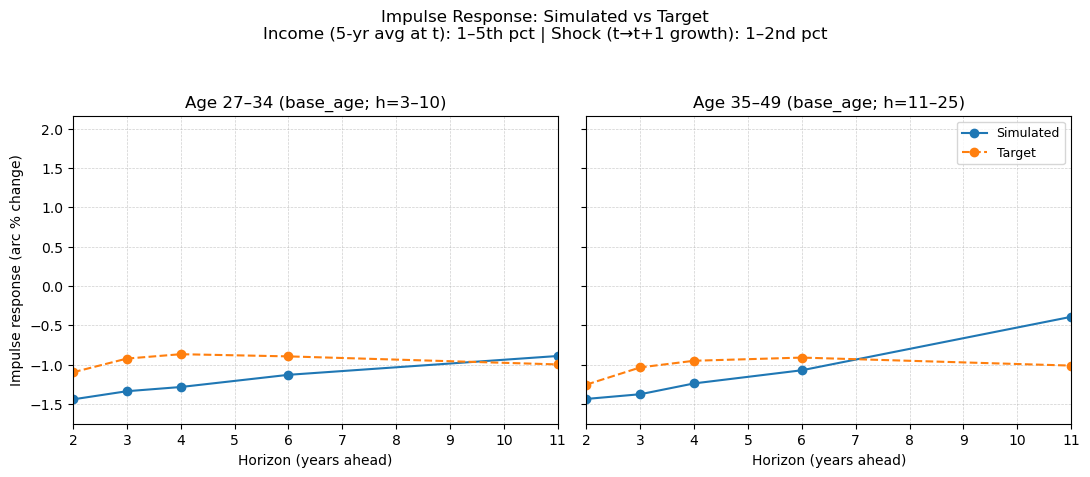

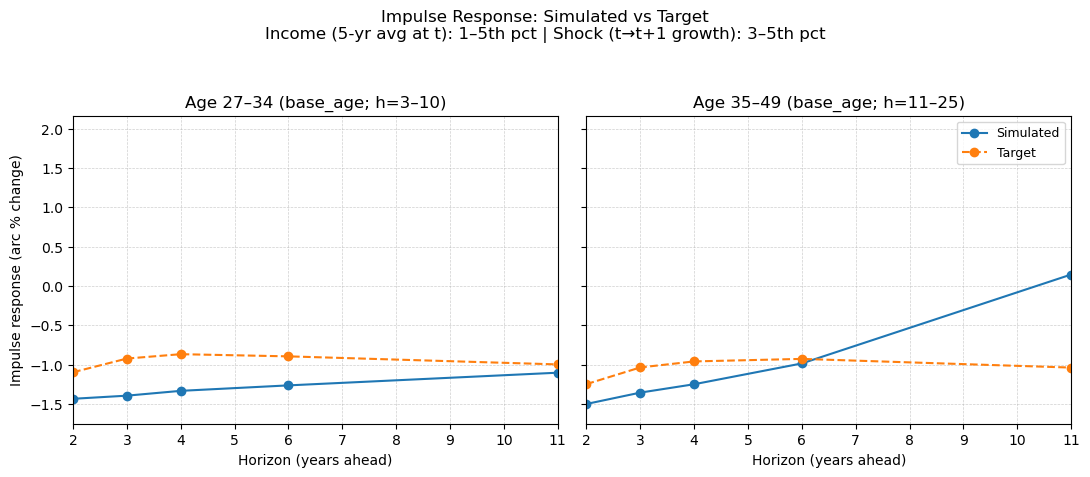

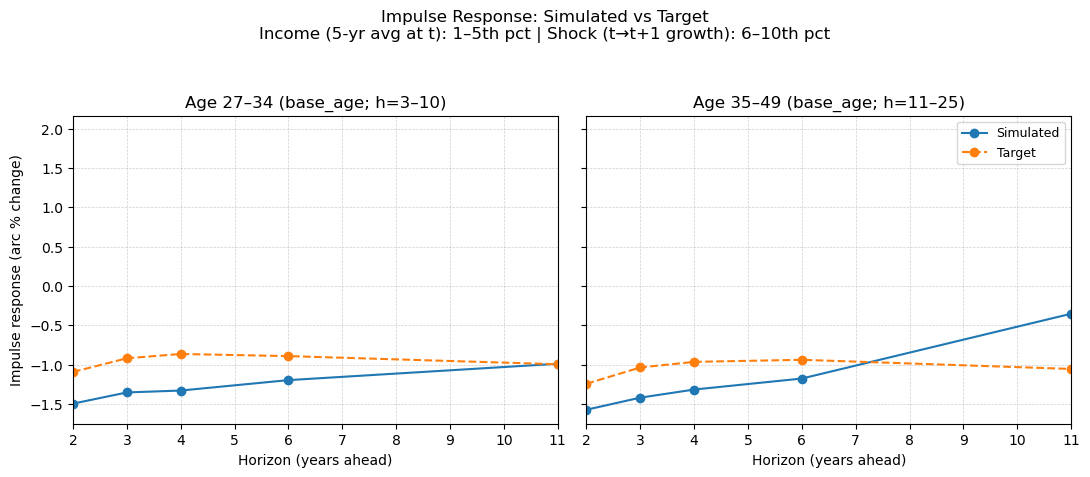

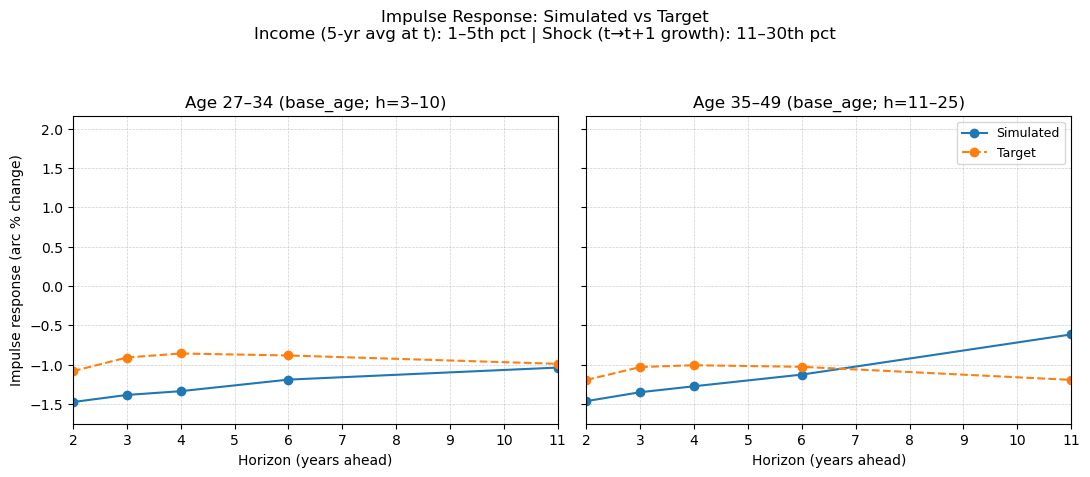

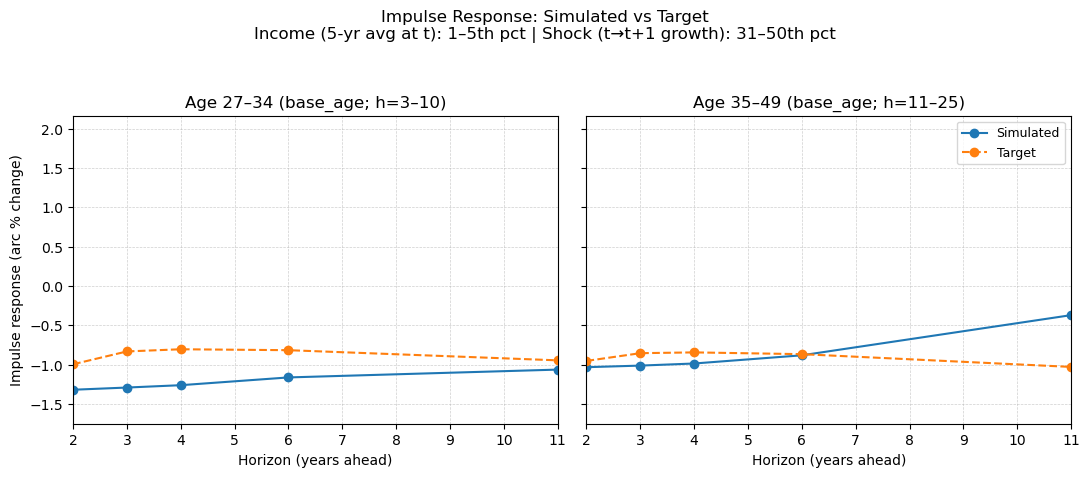

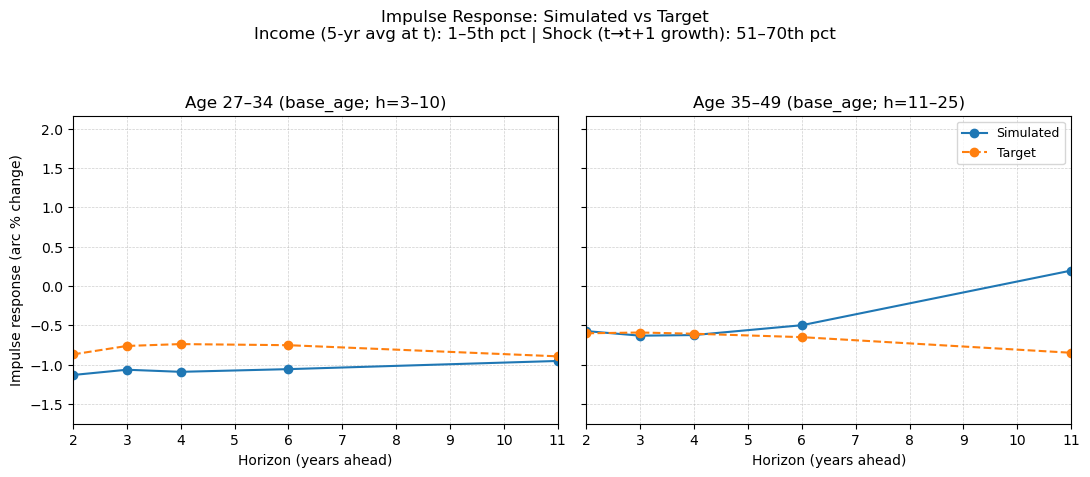

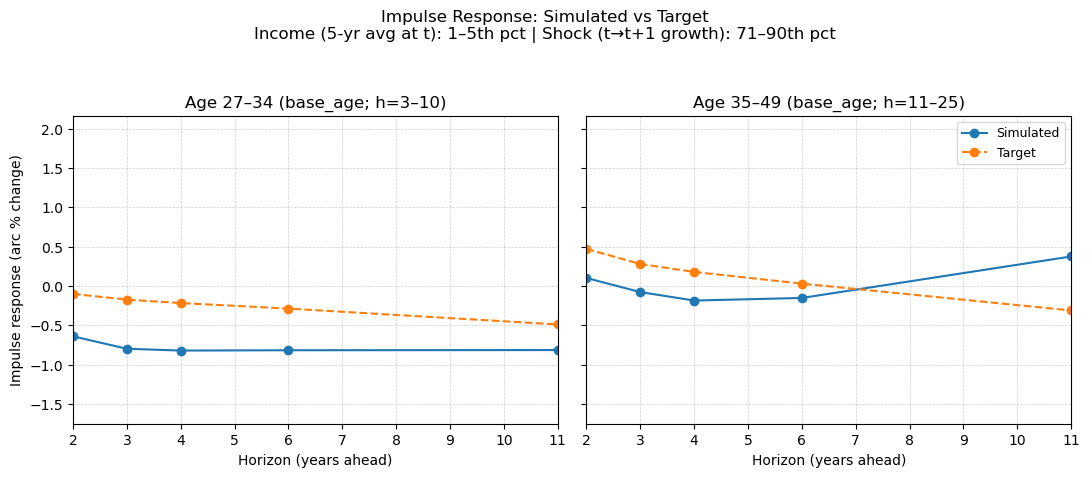

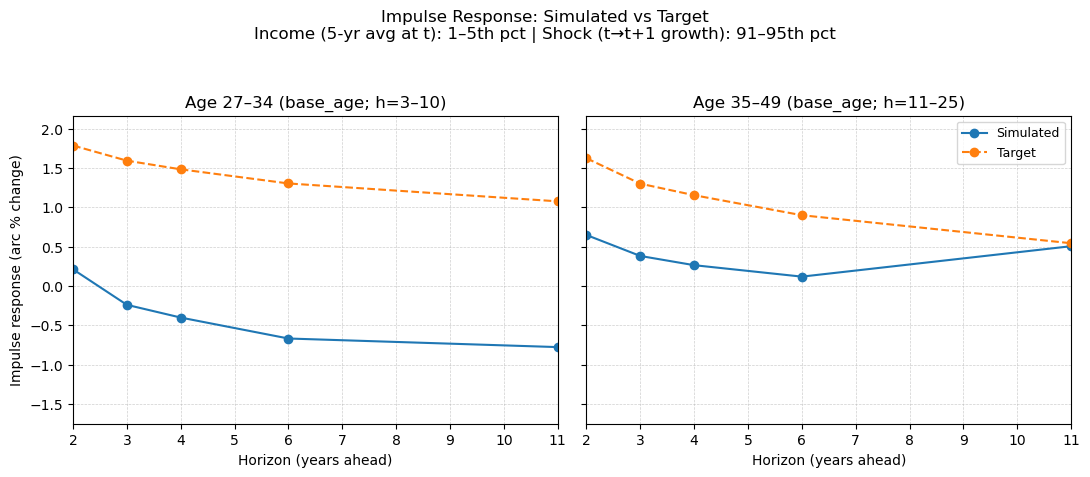

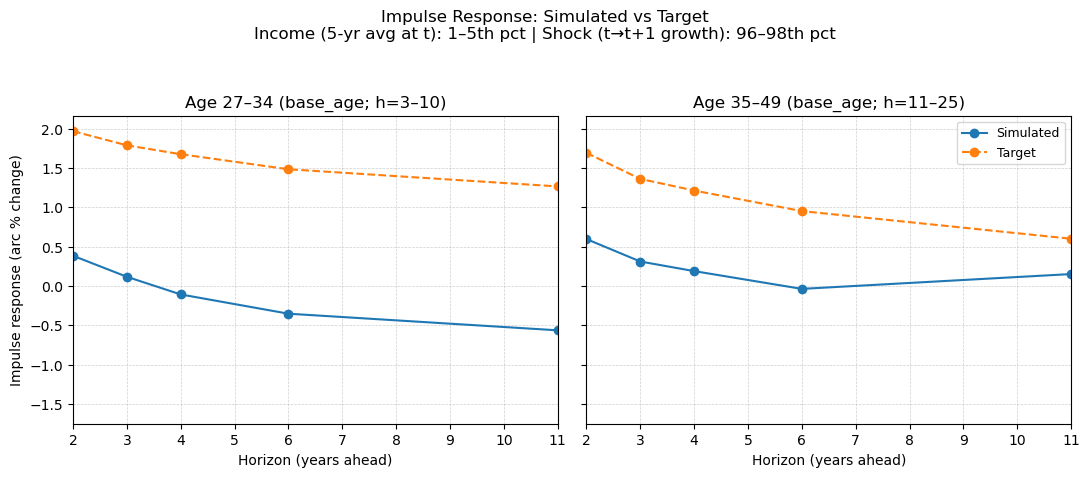

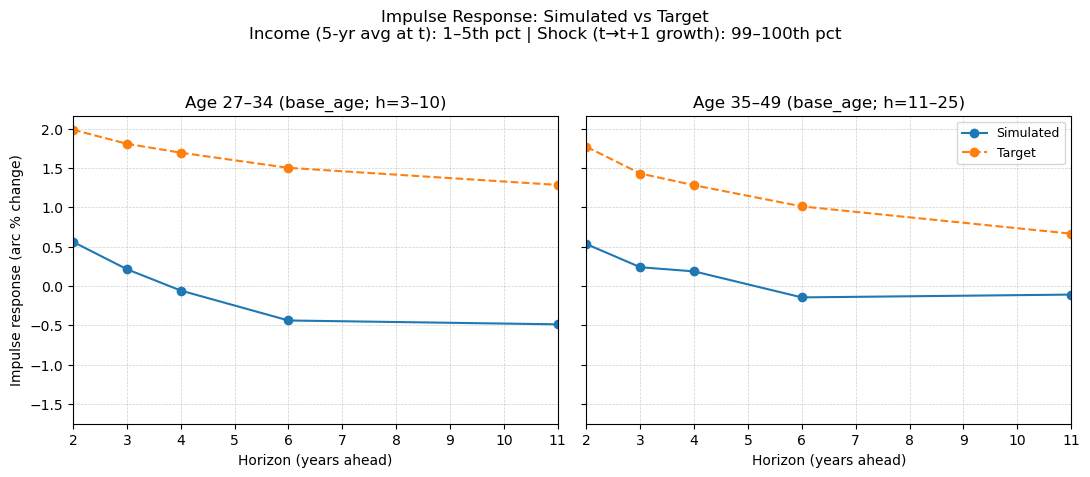

###########################################################################################
###########################################################################################
6–10th pct
###########################################################################################
###########################################################################################


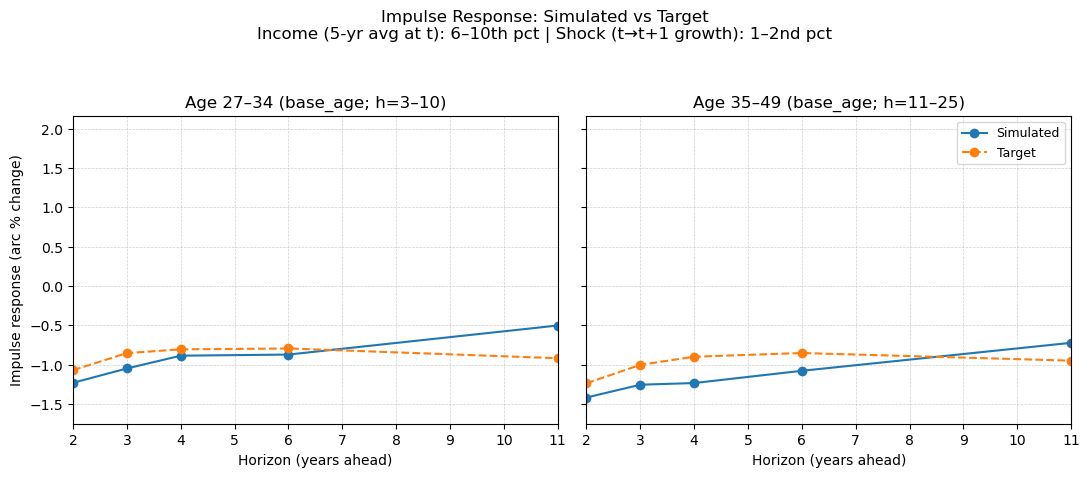

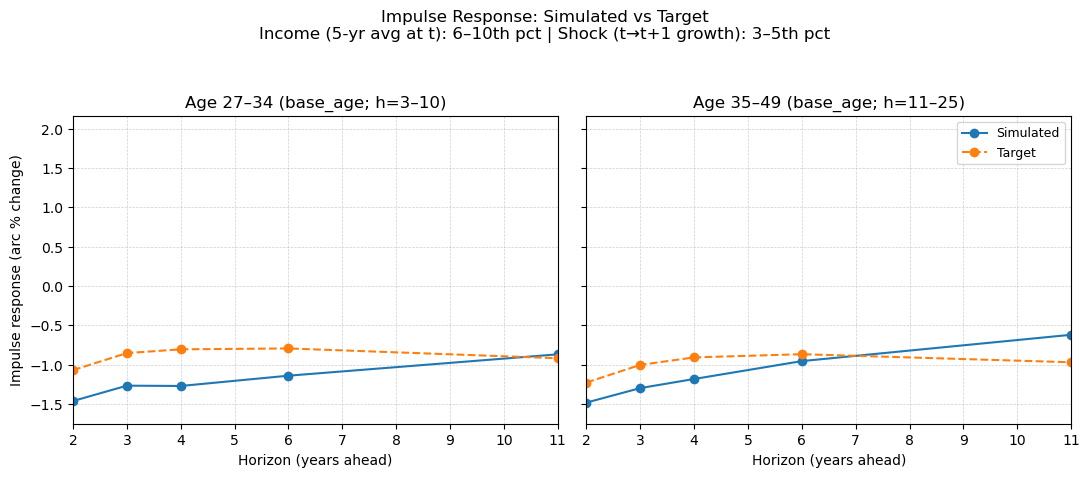

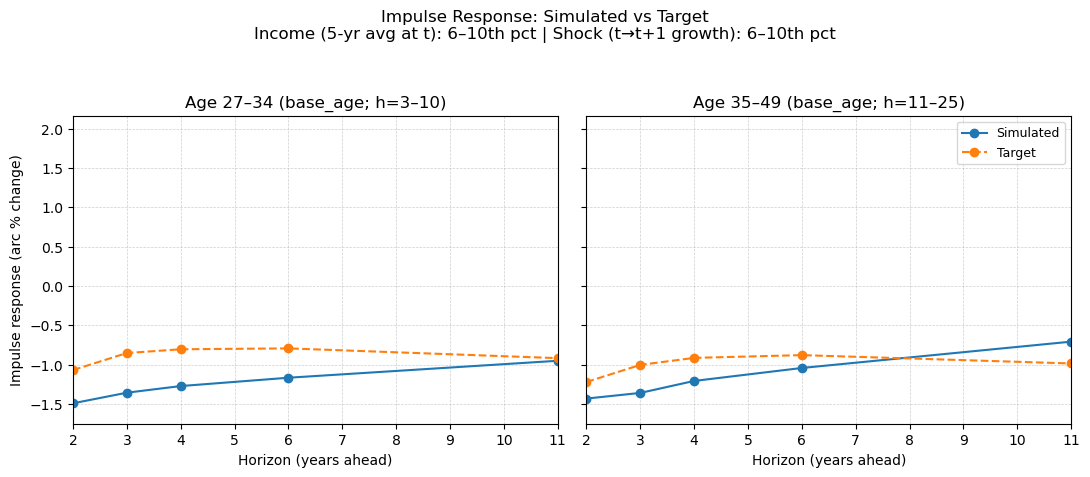

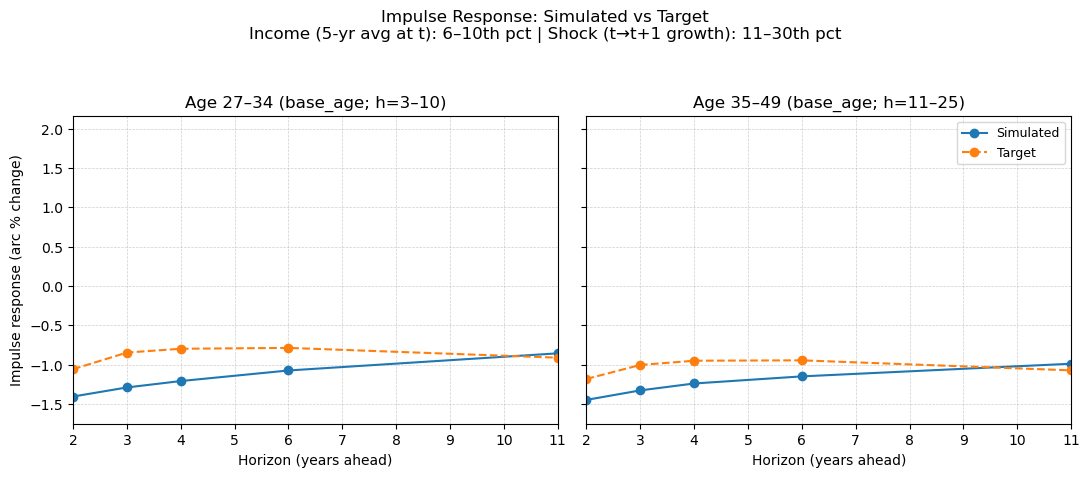

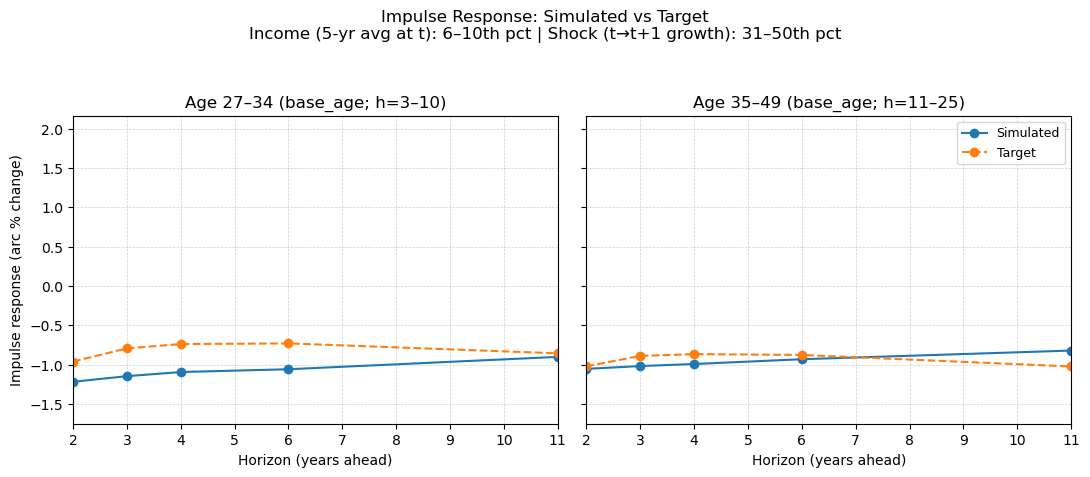

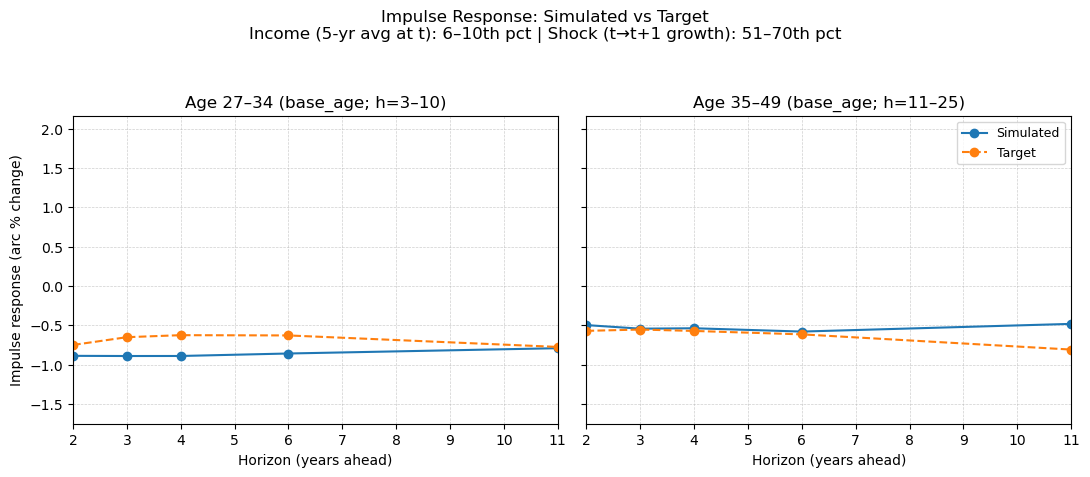

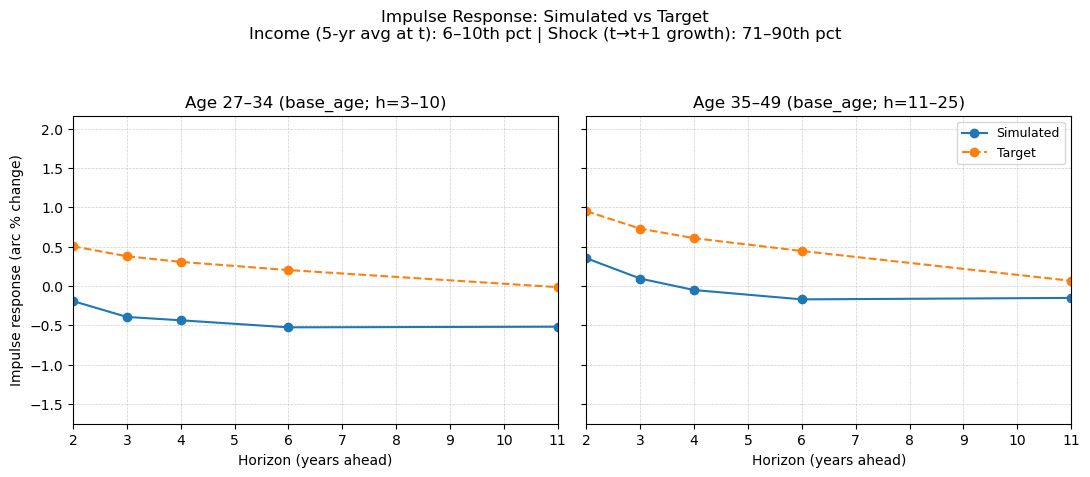

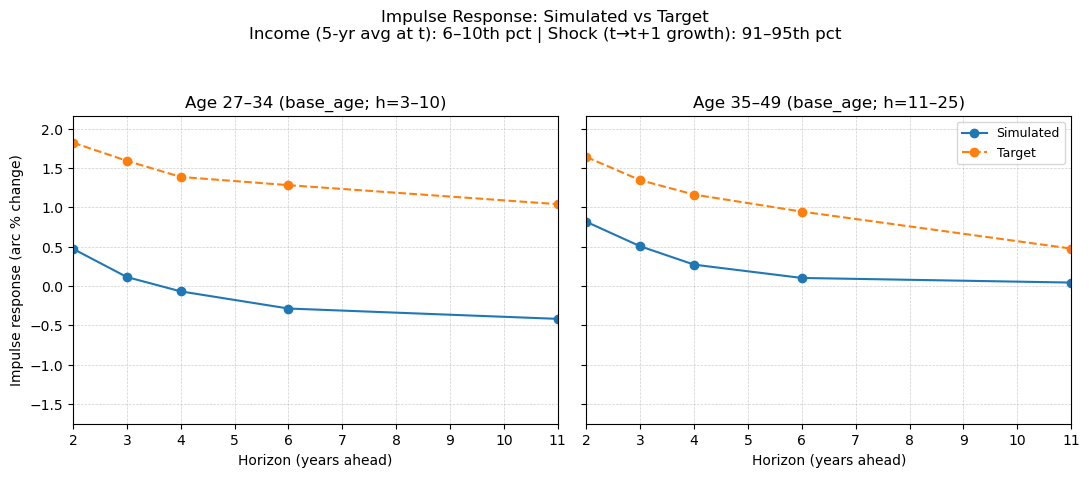

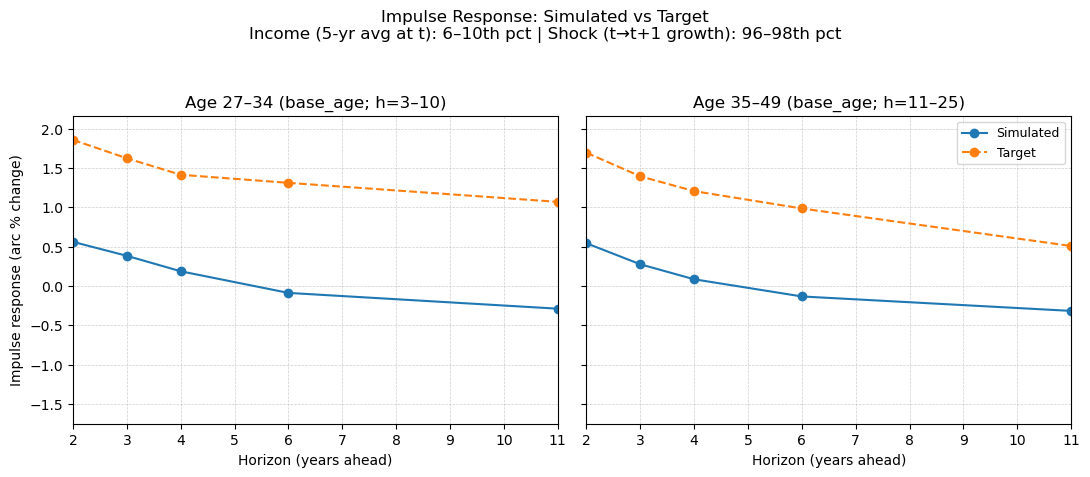

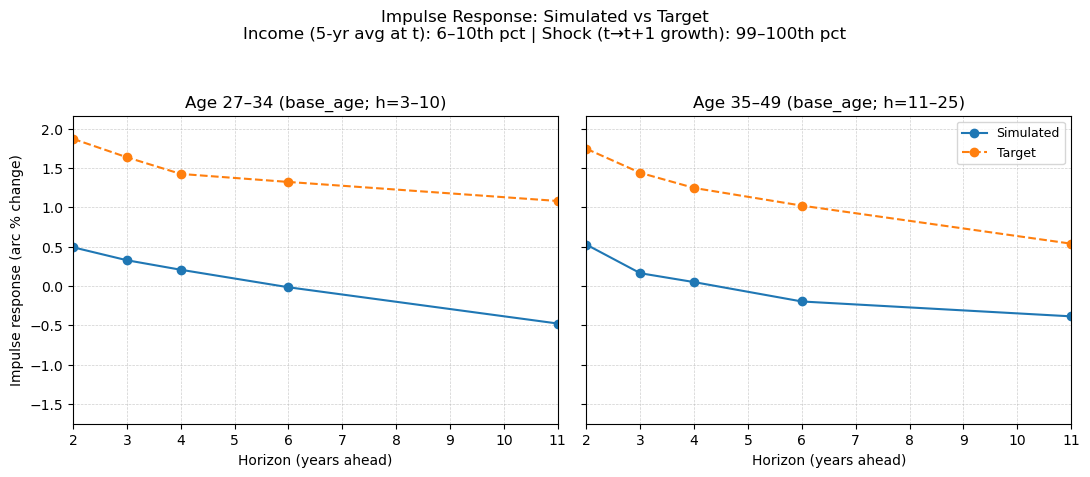

###########################################################################################
###########################################################################################
11–30th pct
###########################################################################################
###########################################################################################


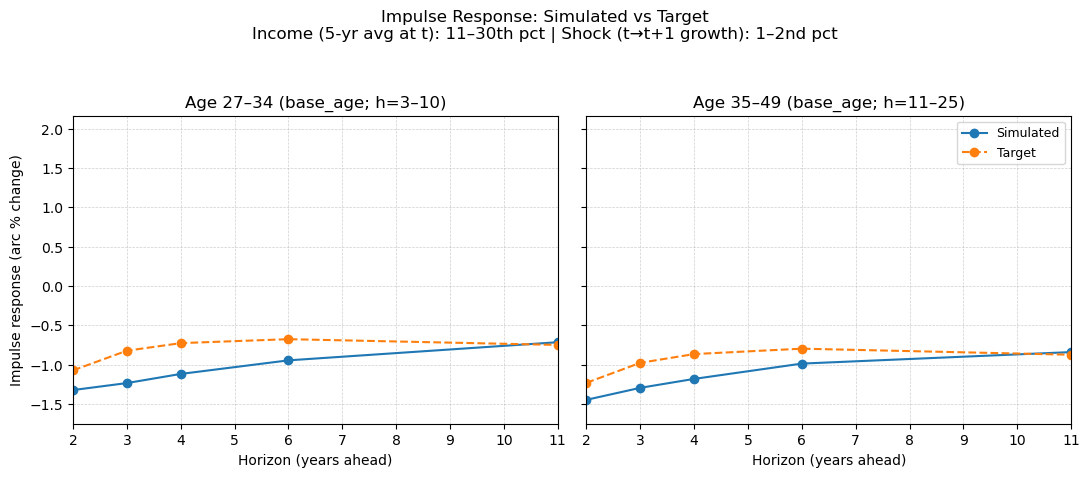

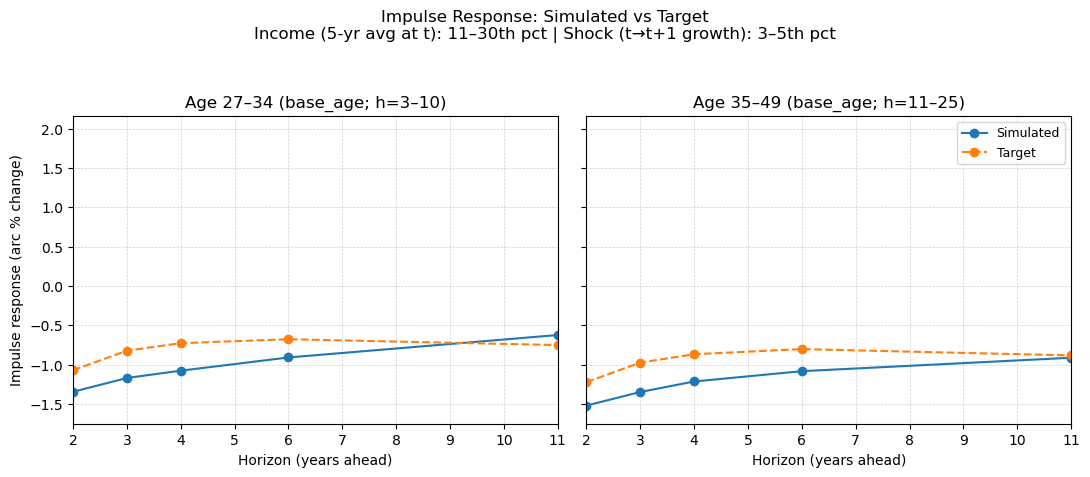

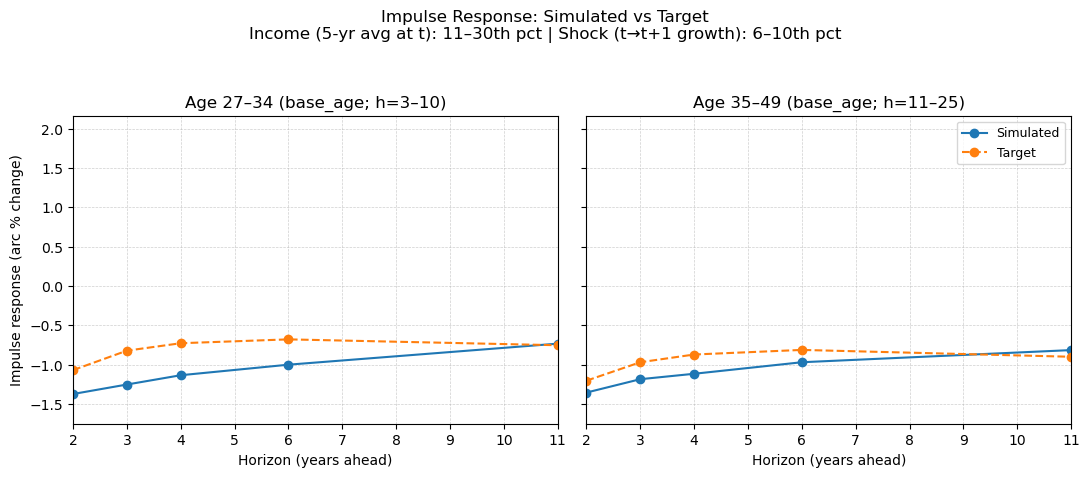

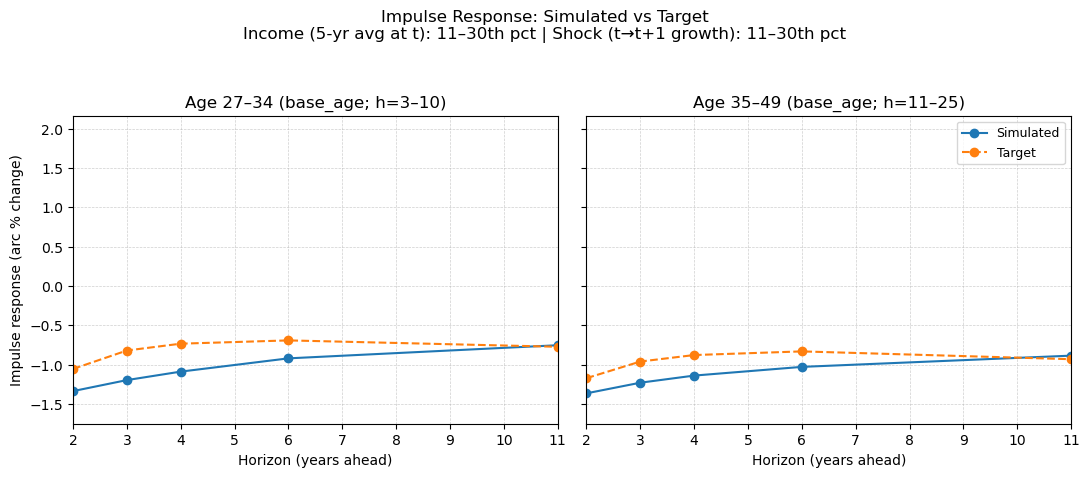

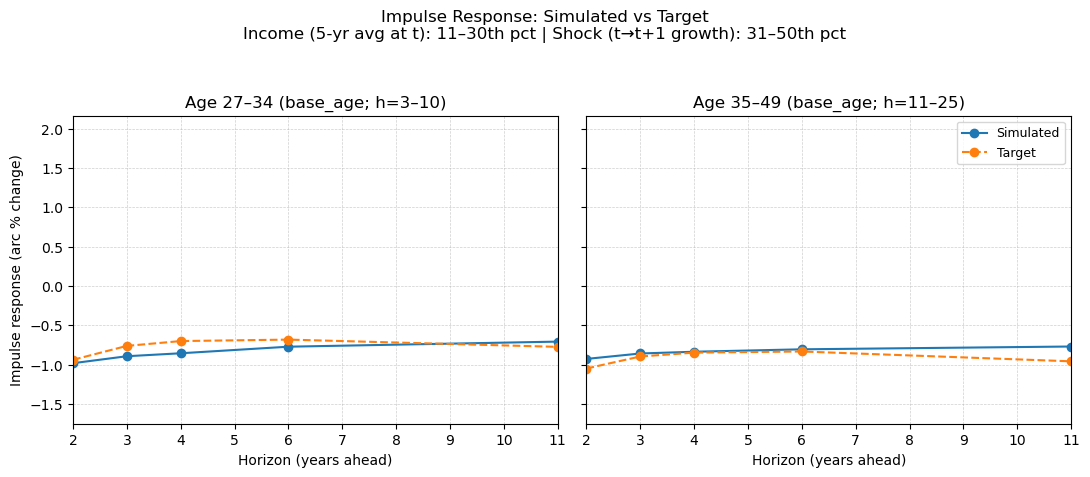

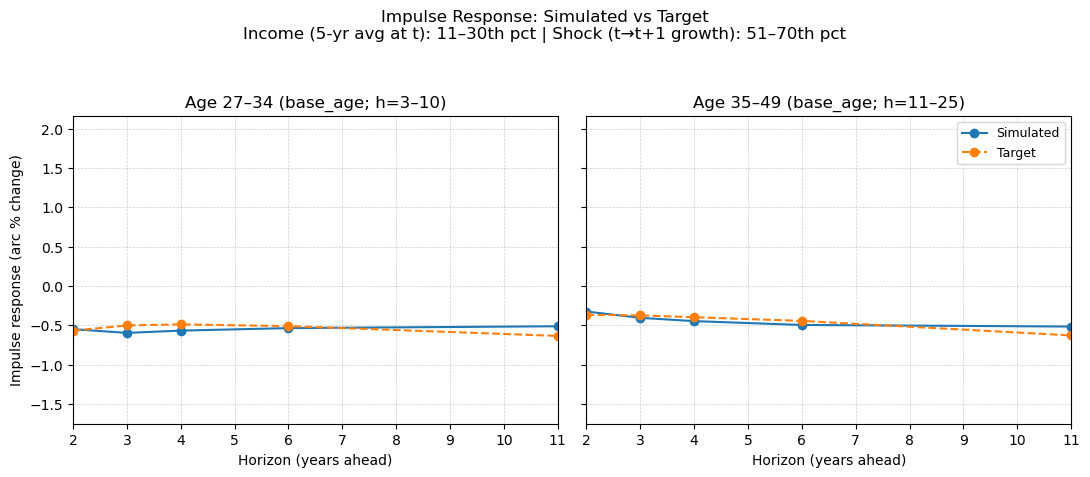

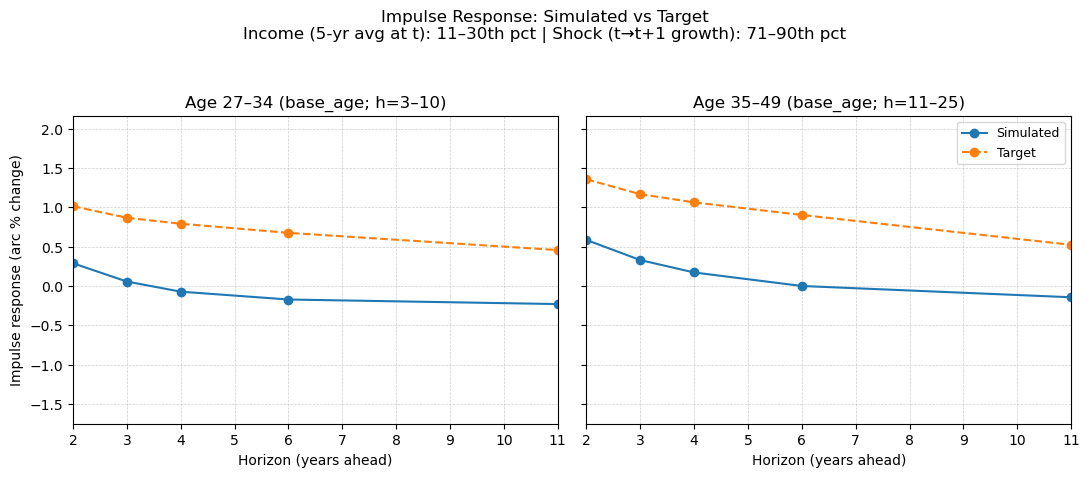

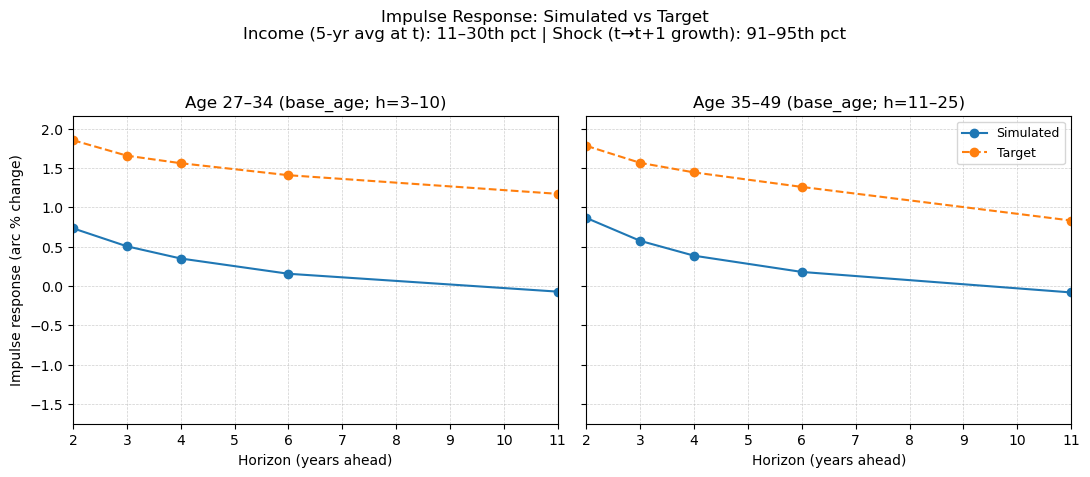

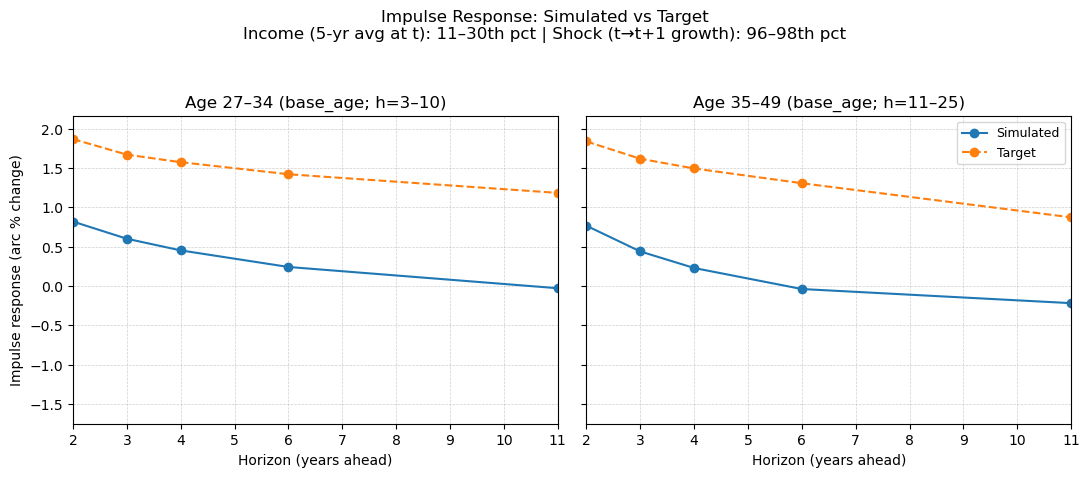

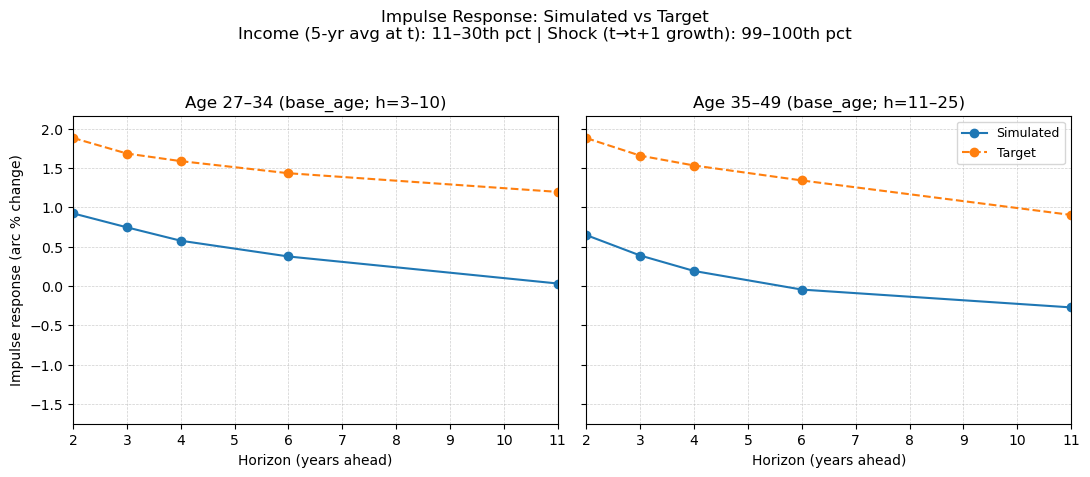

###########################################################################################
###########################################################################################
31–50th pct
###########################################################################################
###########################################################################################


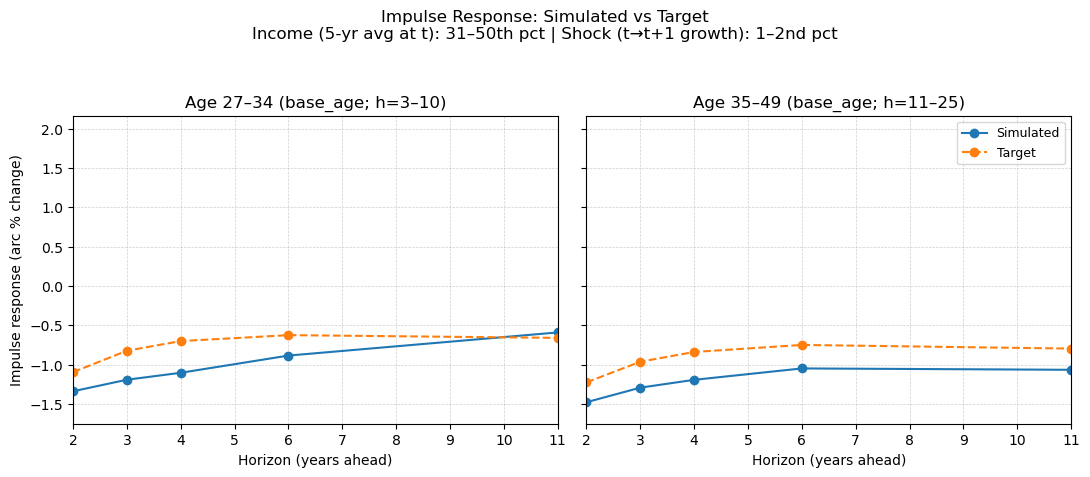

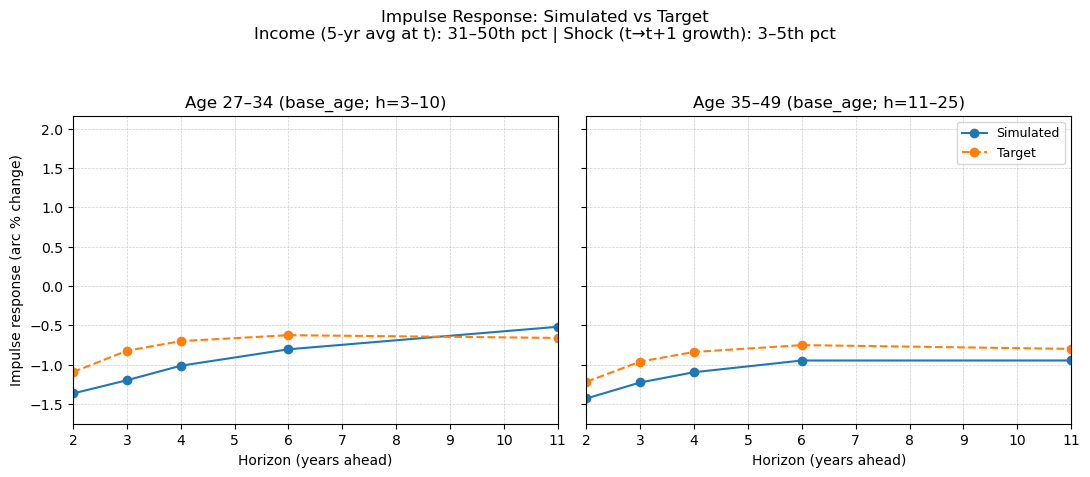

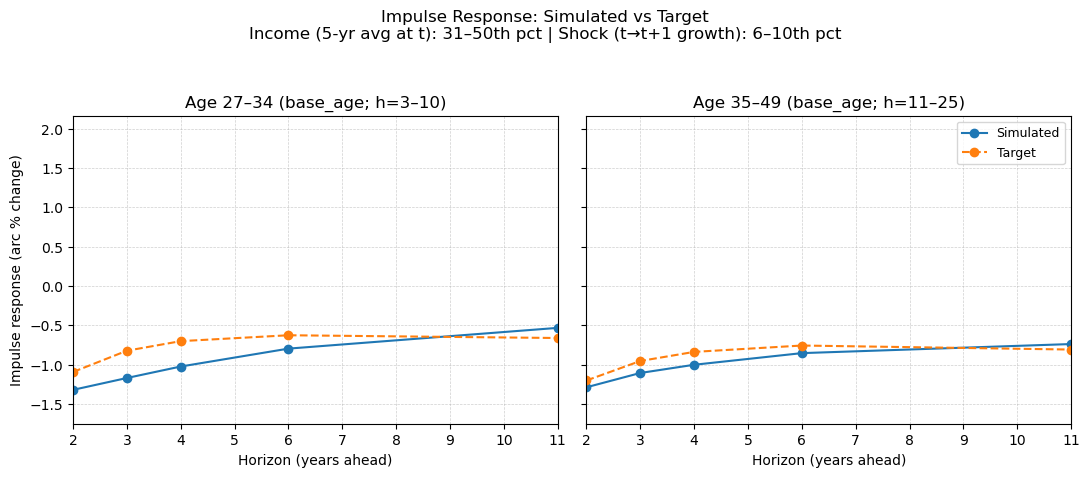

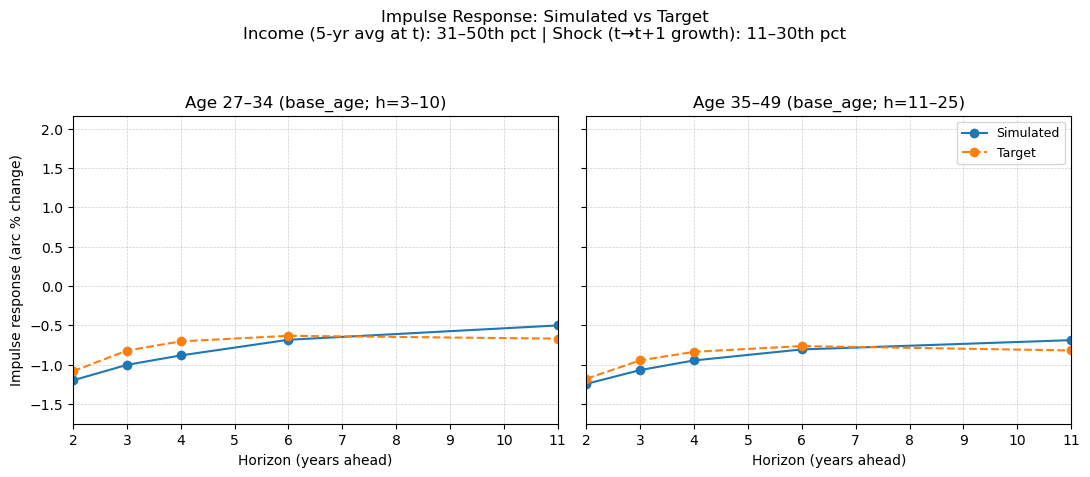

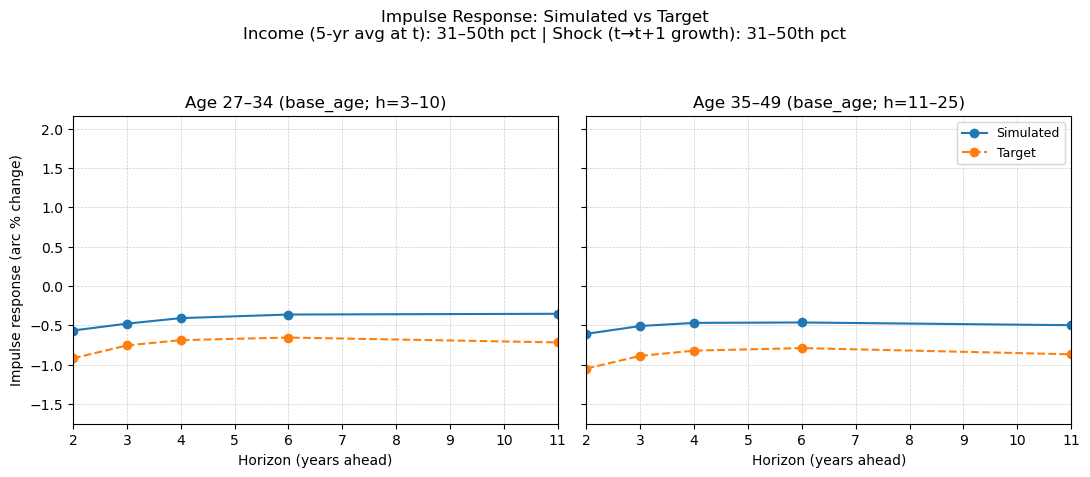

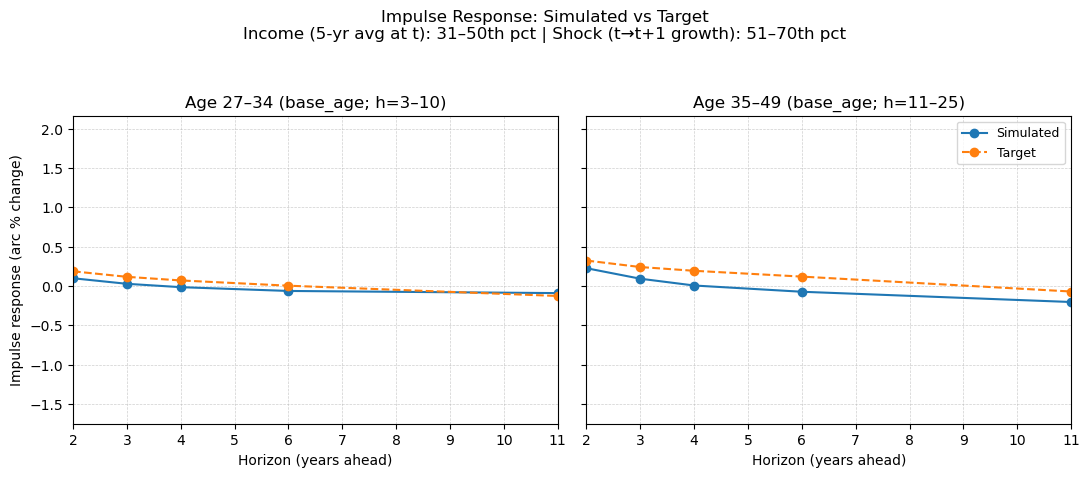

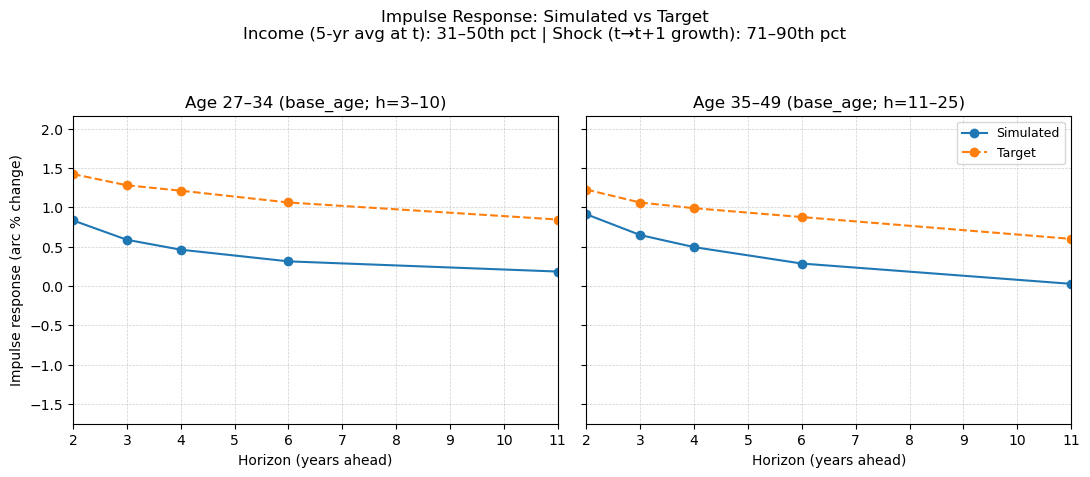

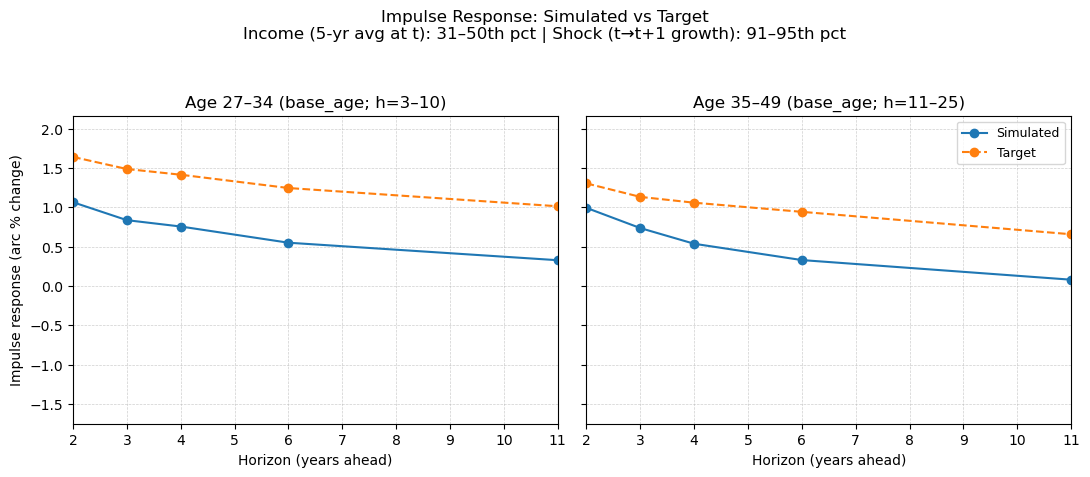

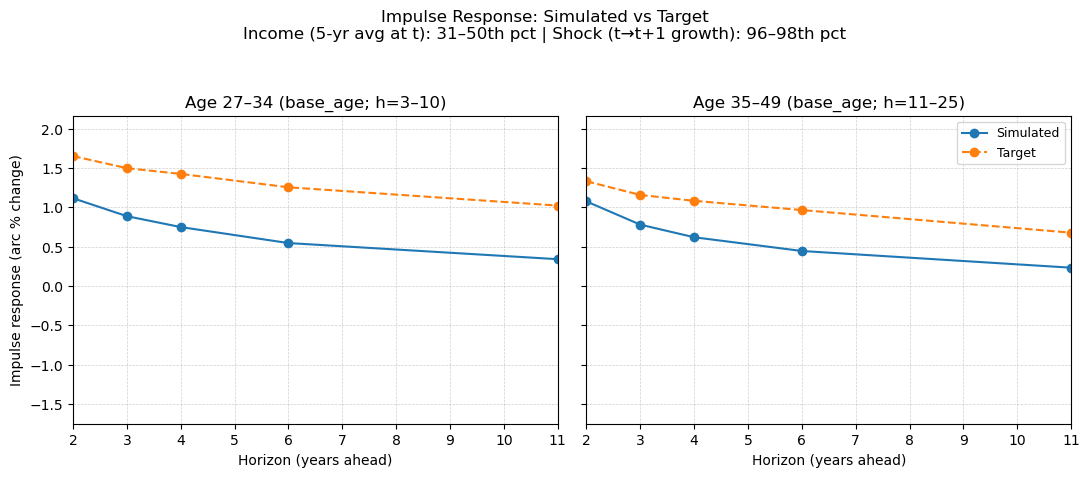

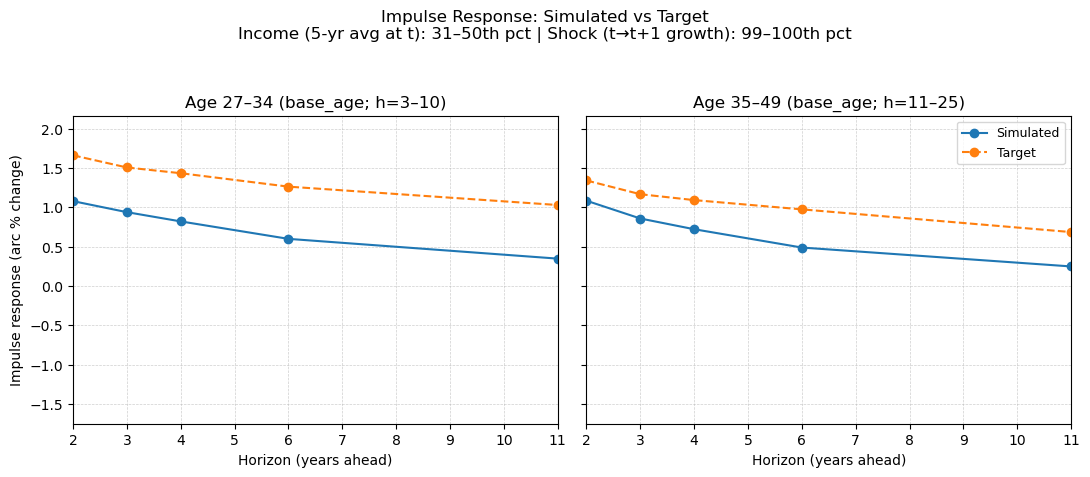

###########################################################################################
###########################################################################################
51–70th pct
###########################################################################################
###########################################################################################


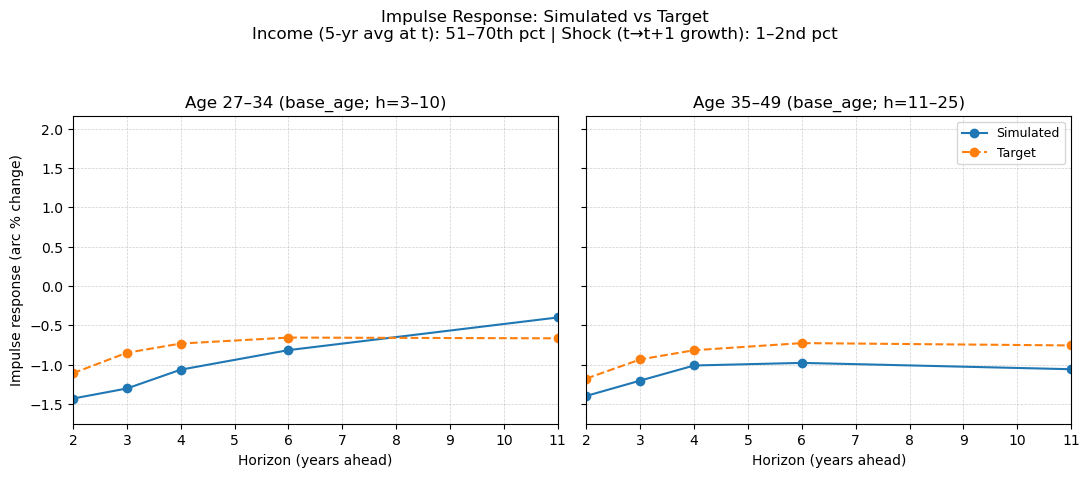

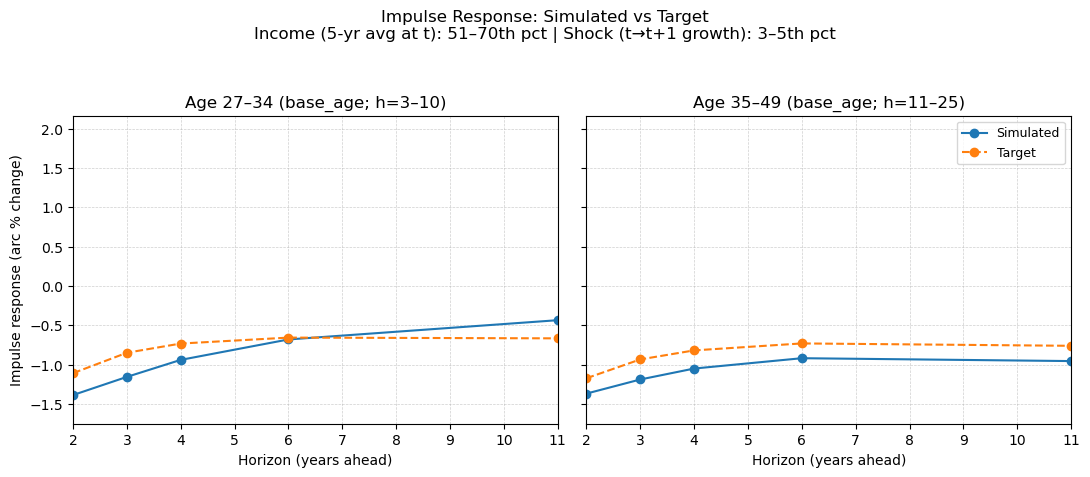

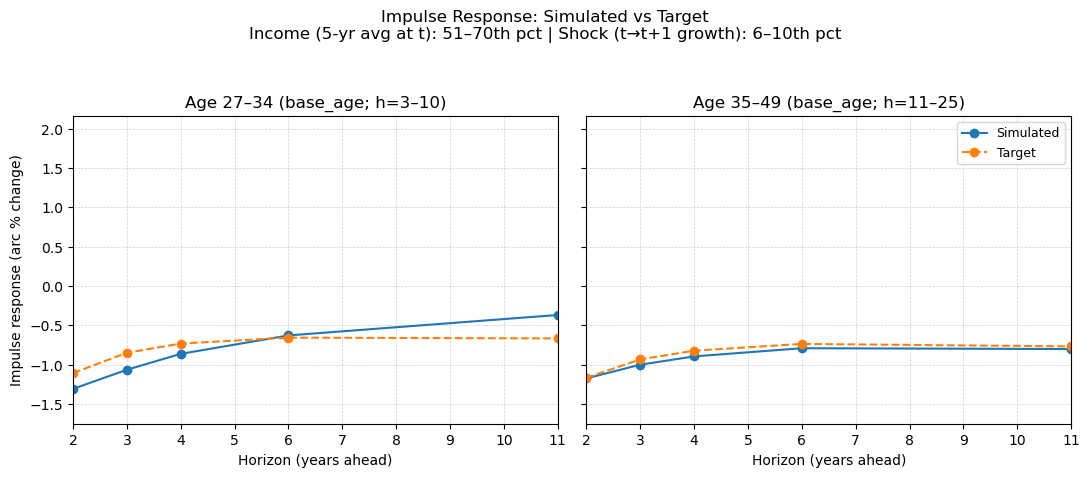

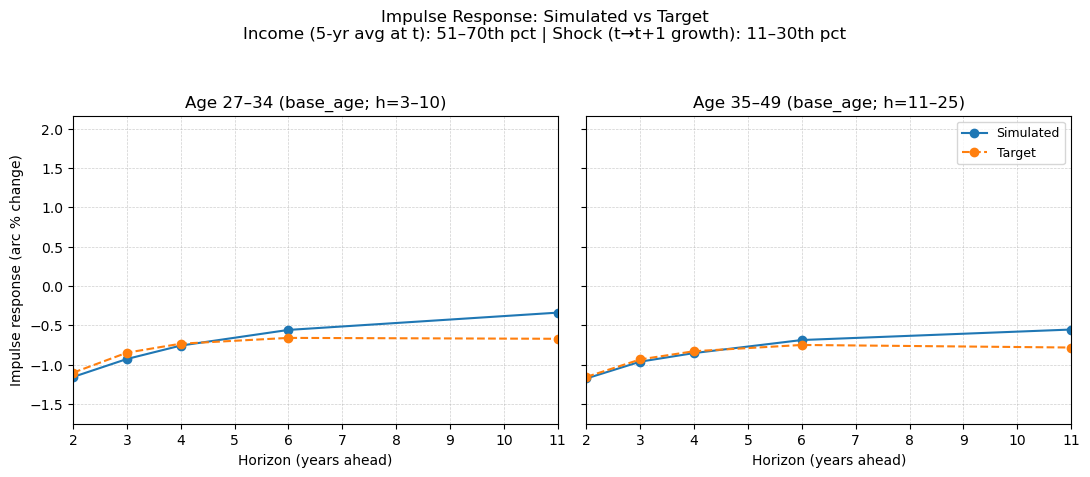

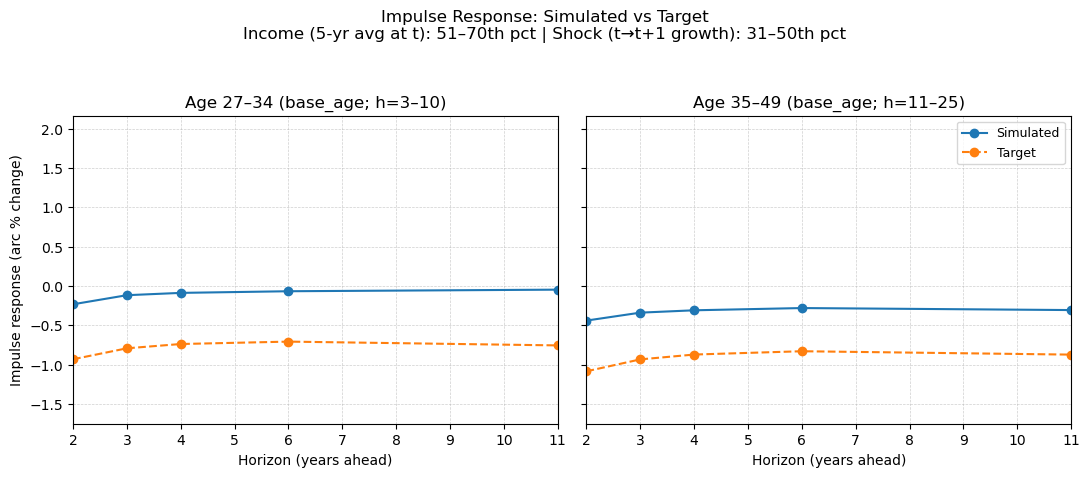

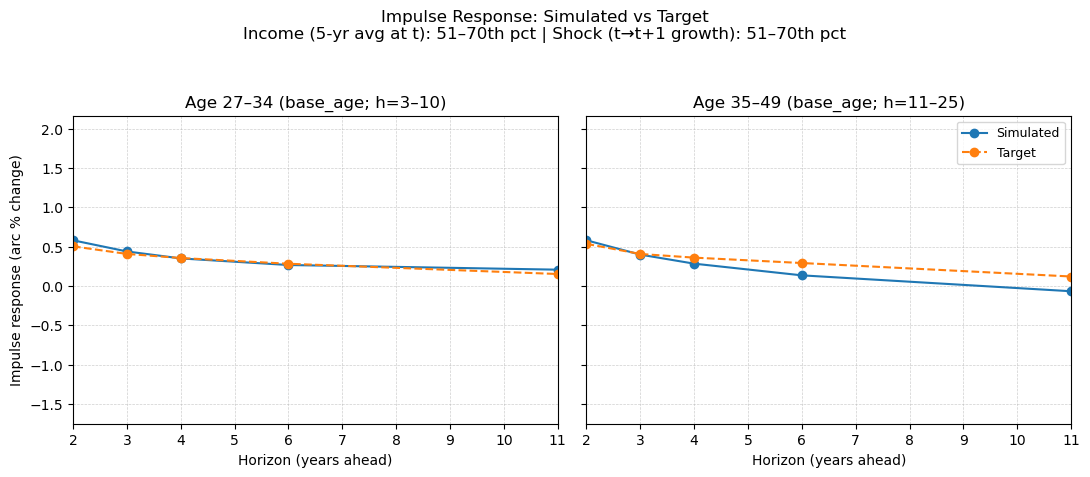

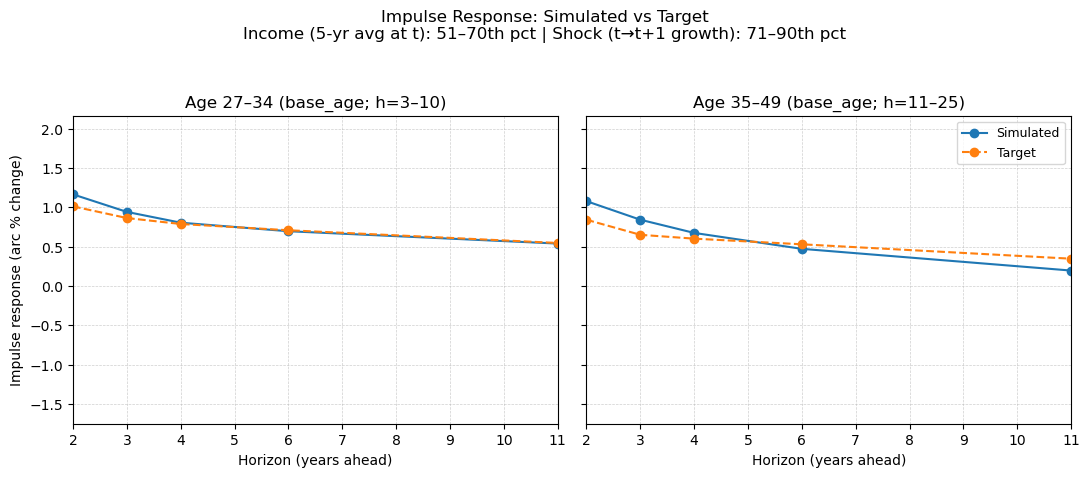

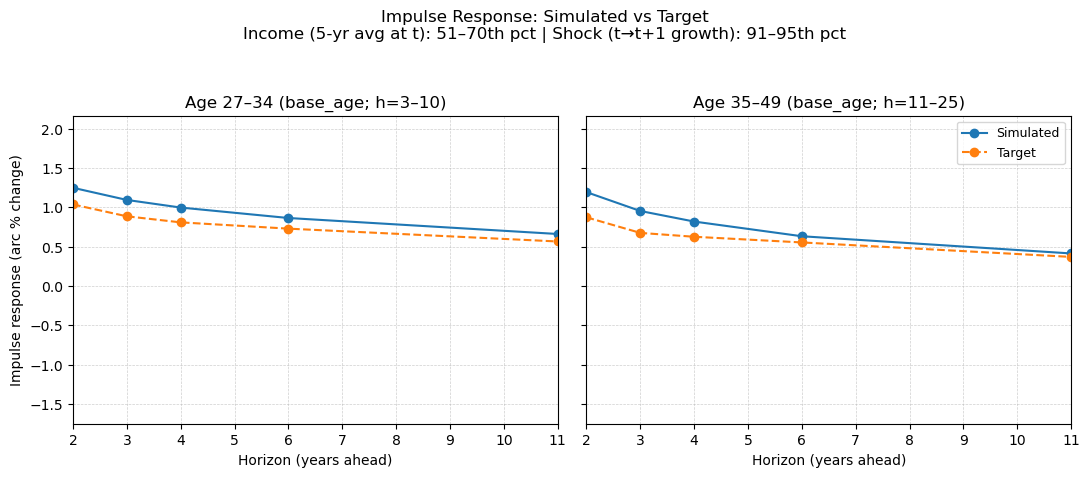

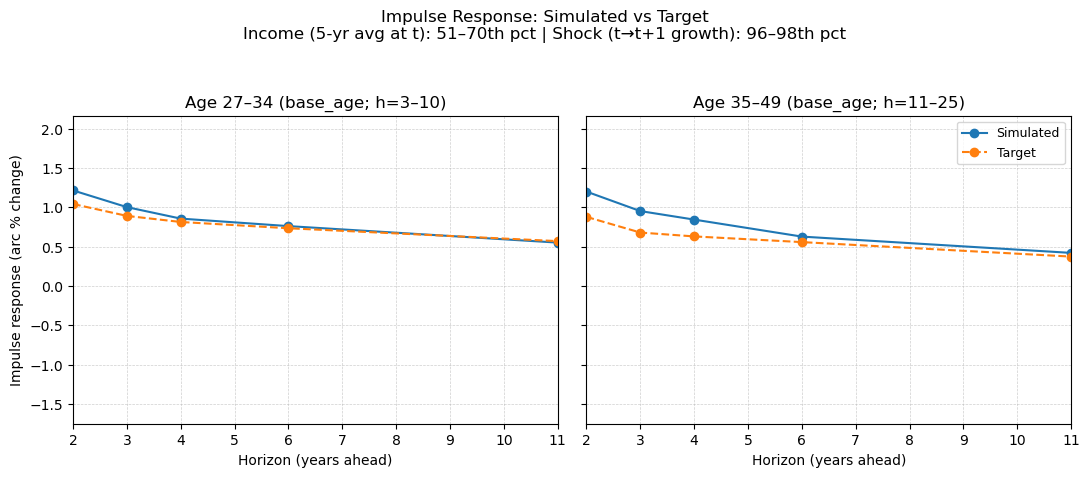

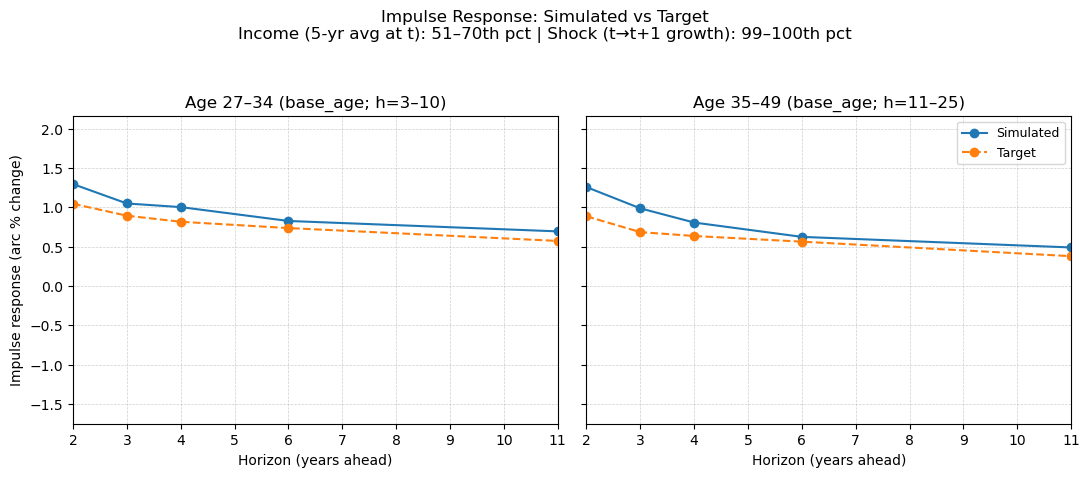

###########################################################################################
###########################################################################################
71–90th pct
###########################################################################################
###########################################################################################


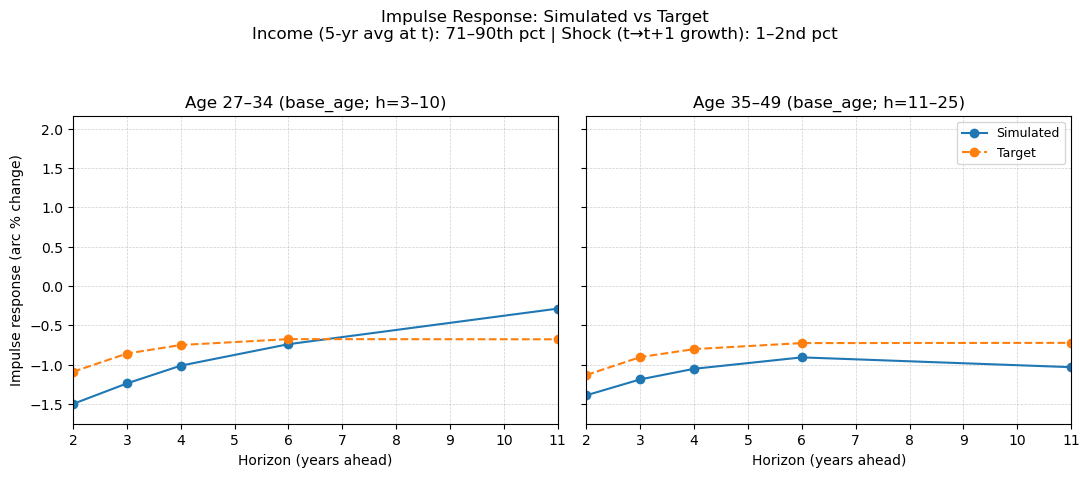

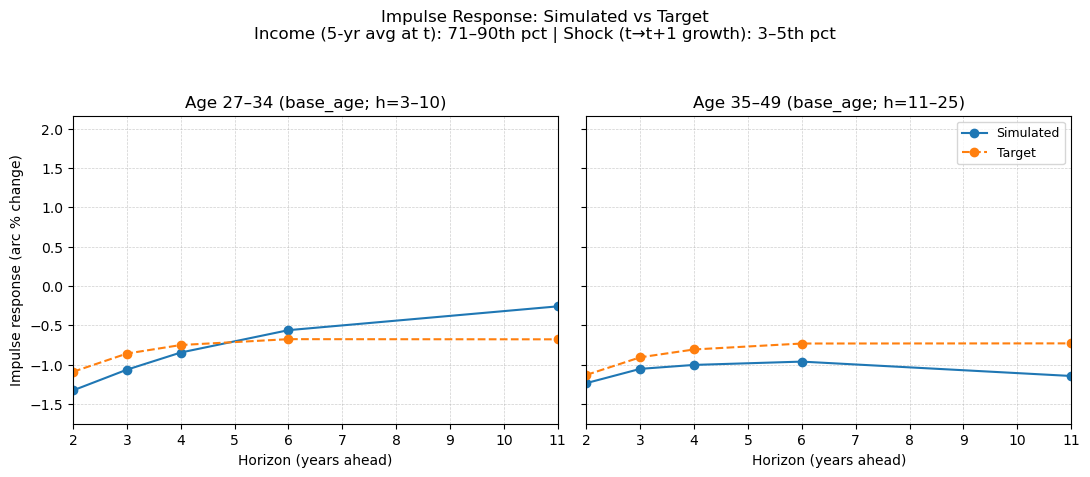

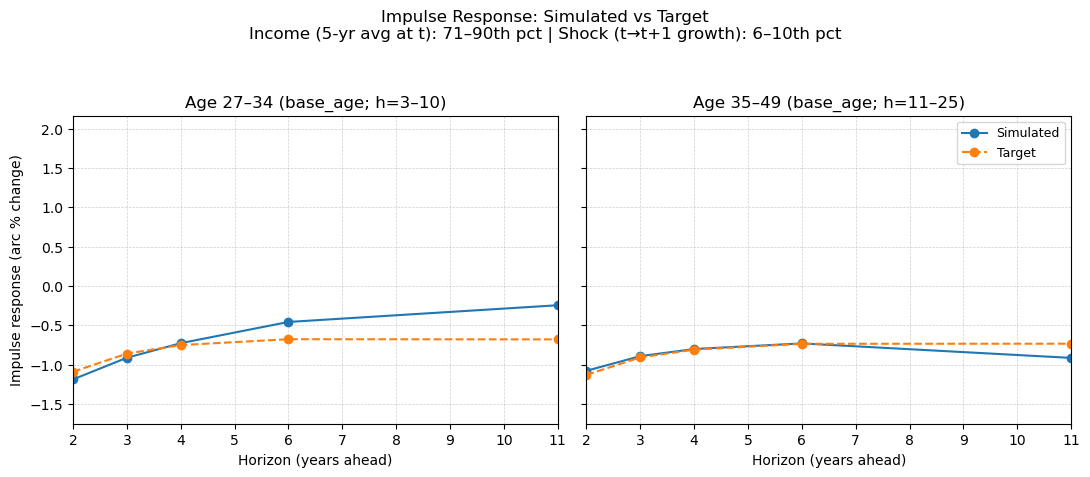

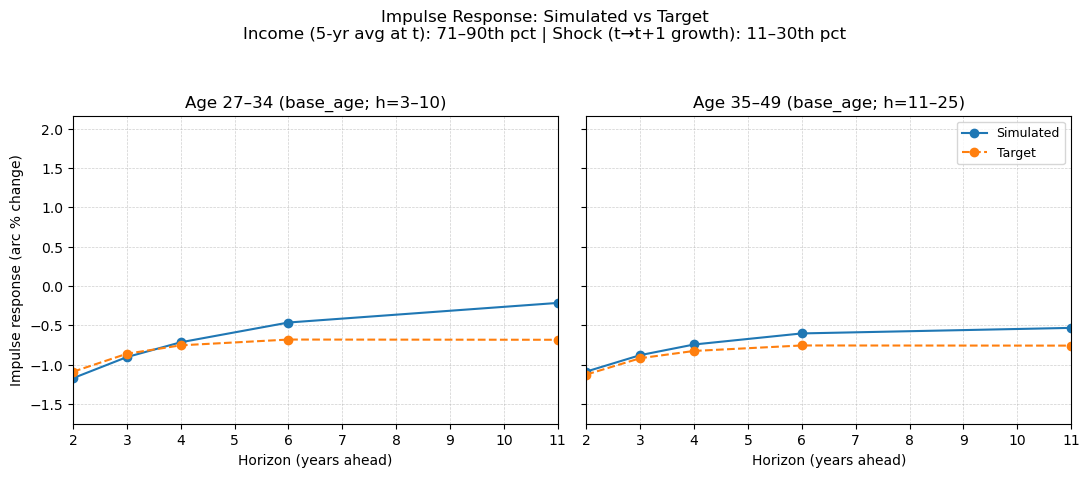

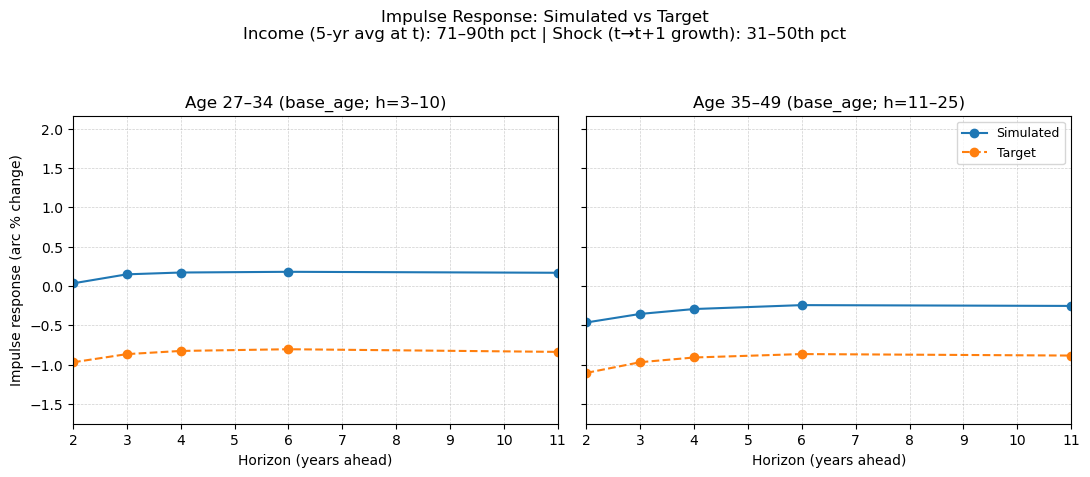

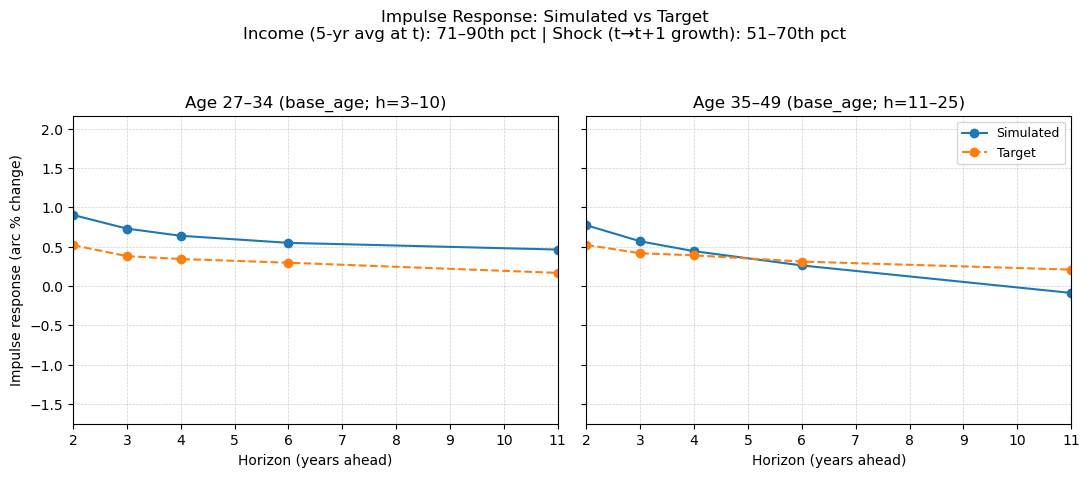

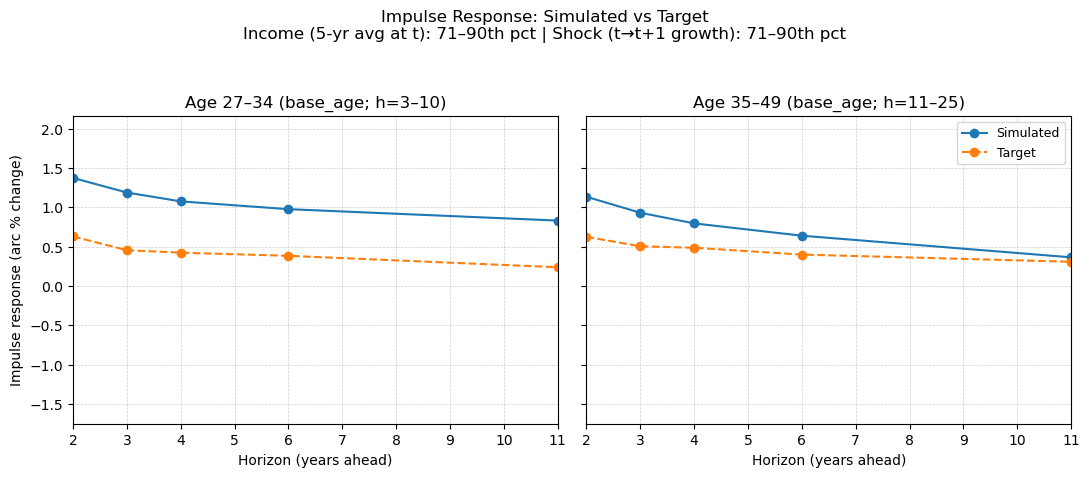

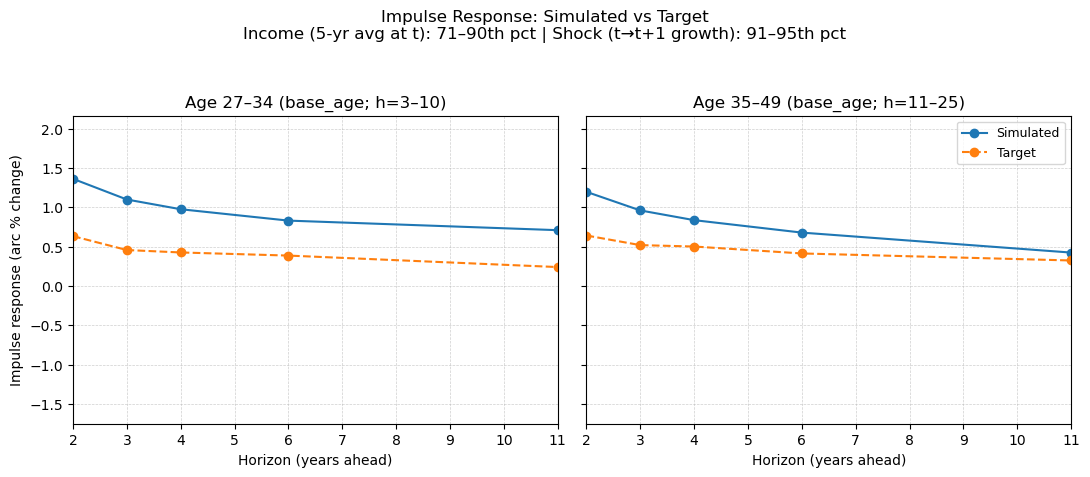

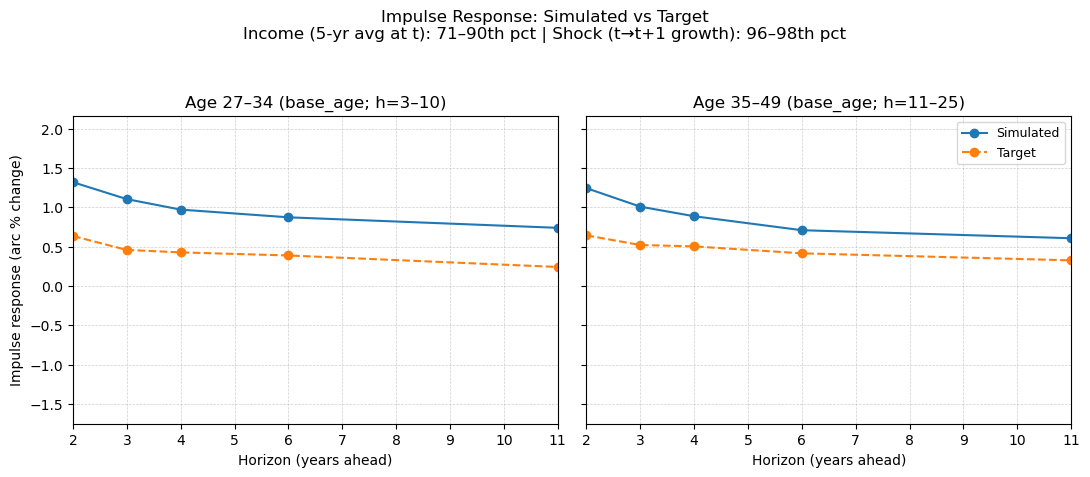

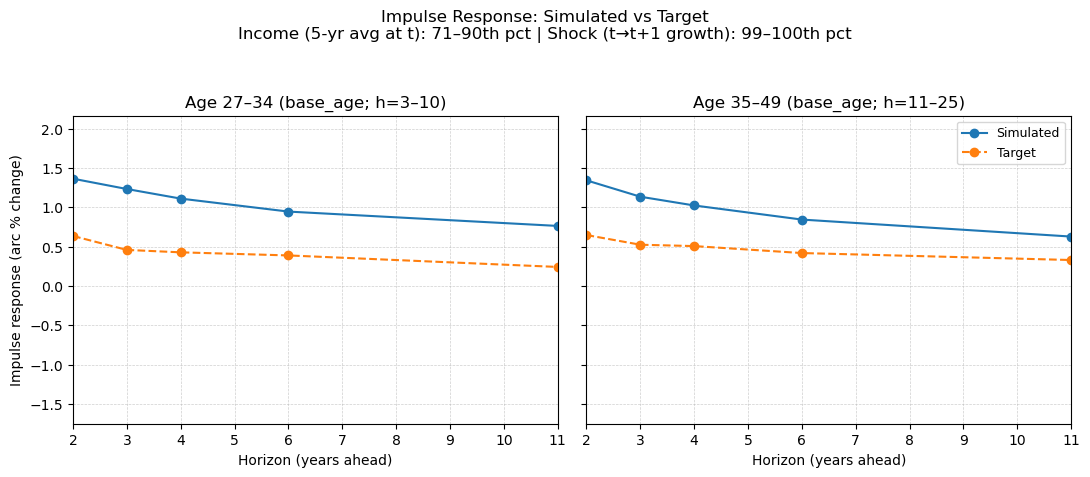

###########################################################################################
###########################################################################################
91–95th pct
###########################################################################################
###########################################################################################


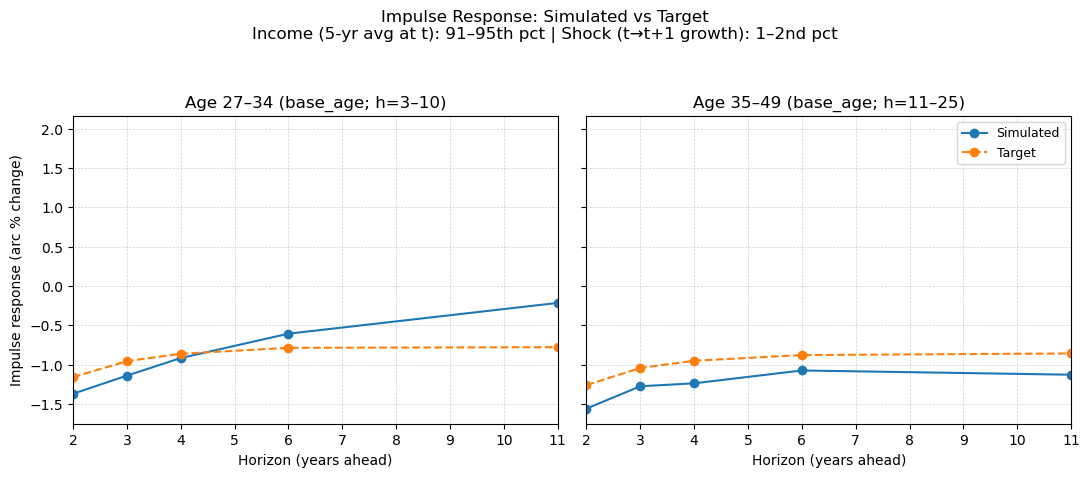

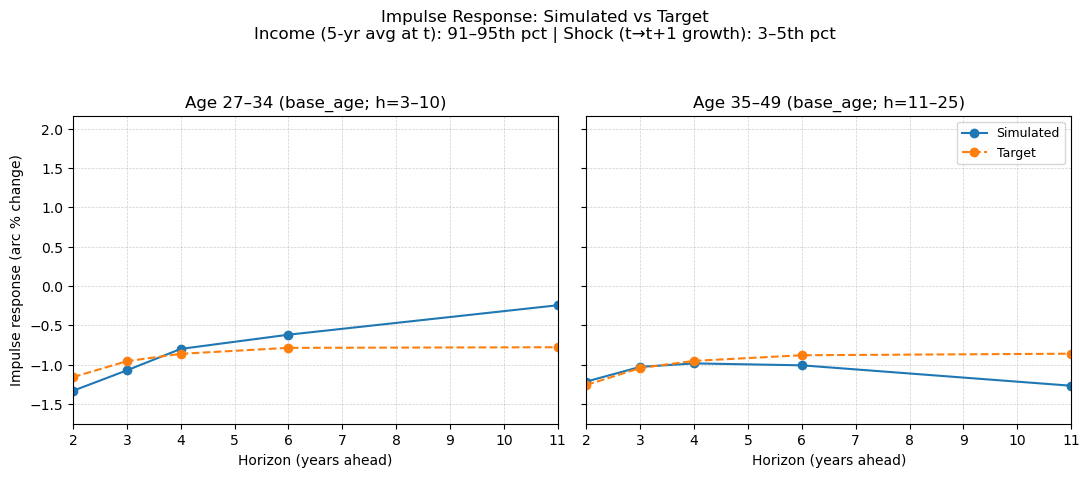

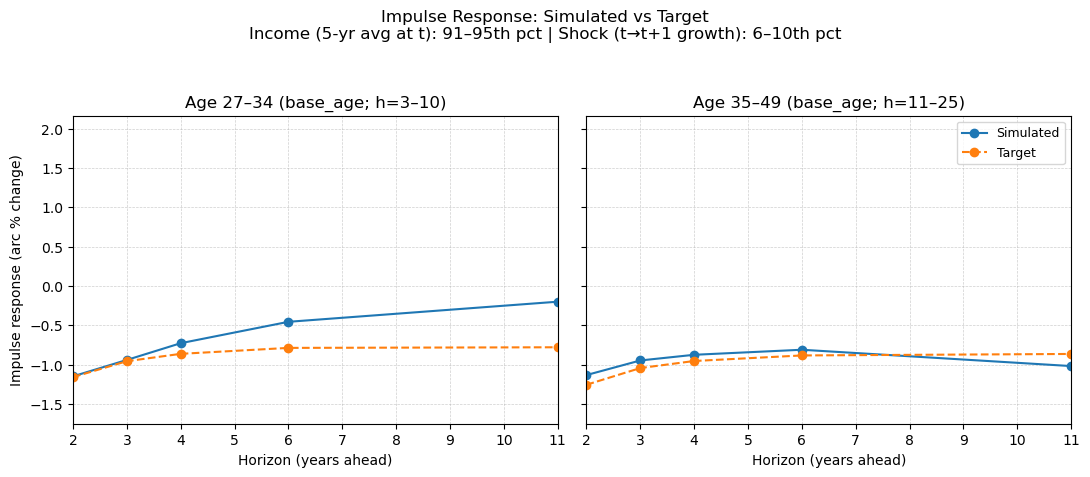

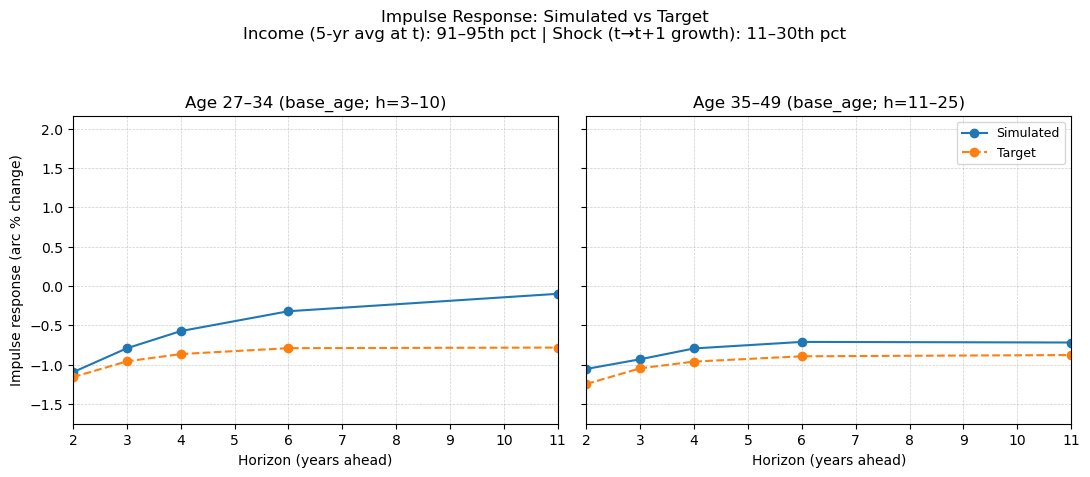

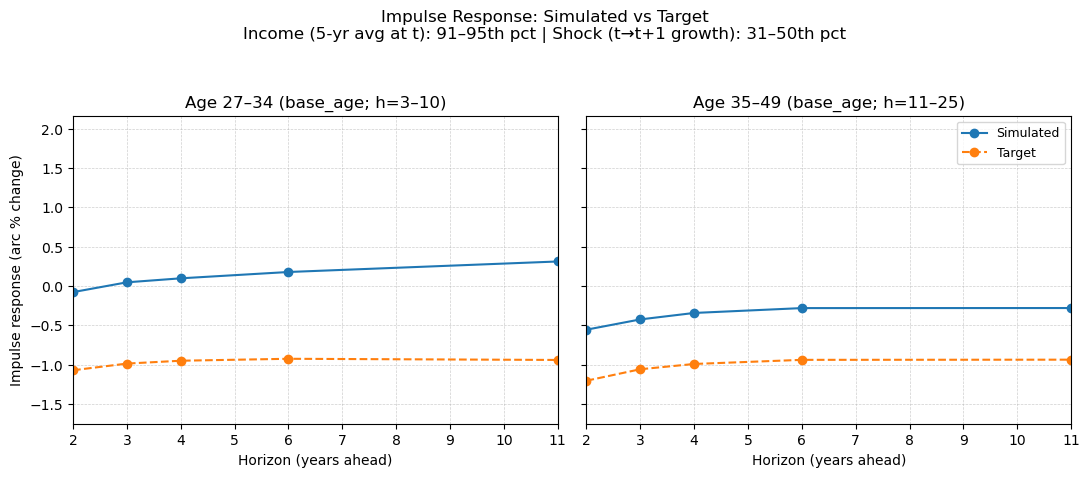

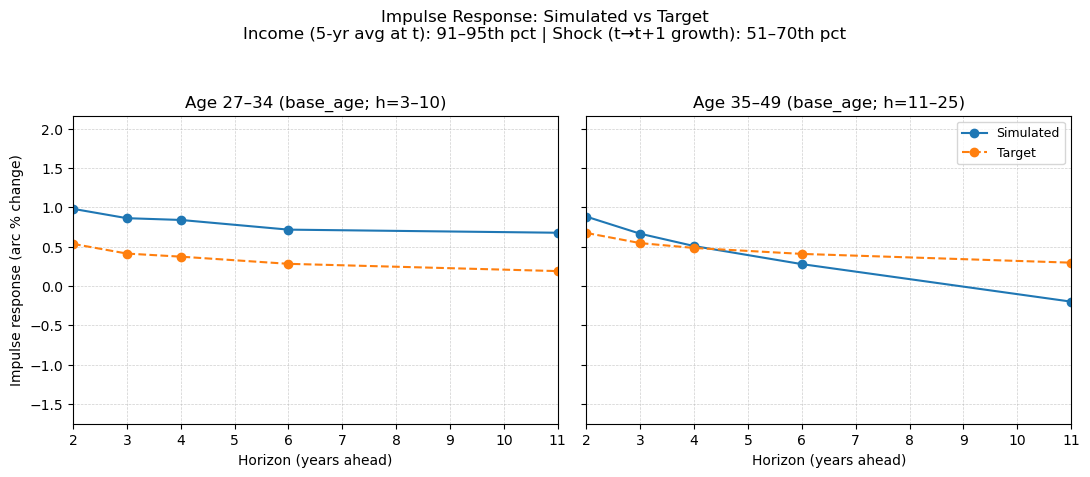

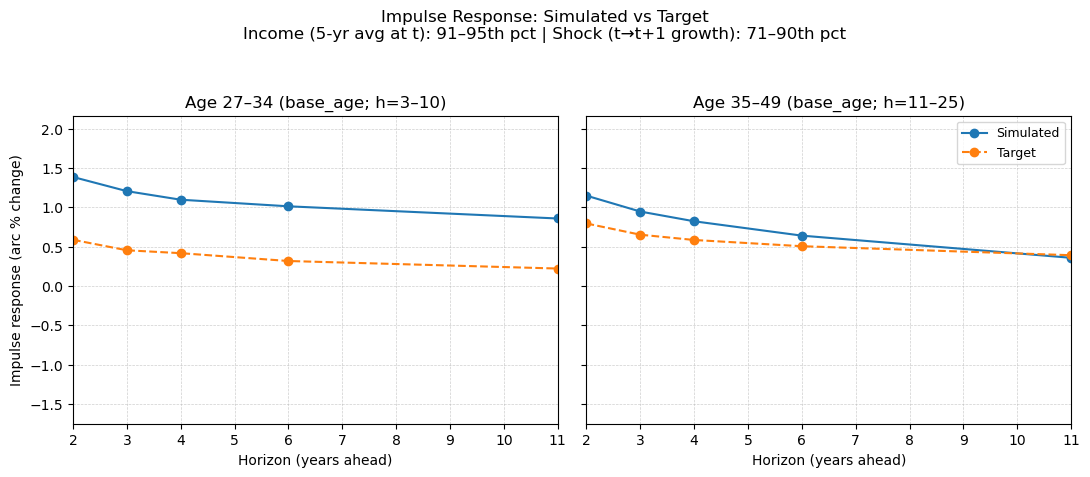

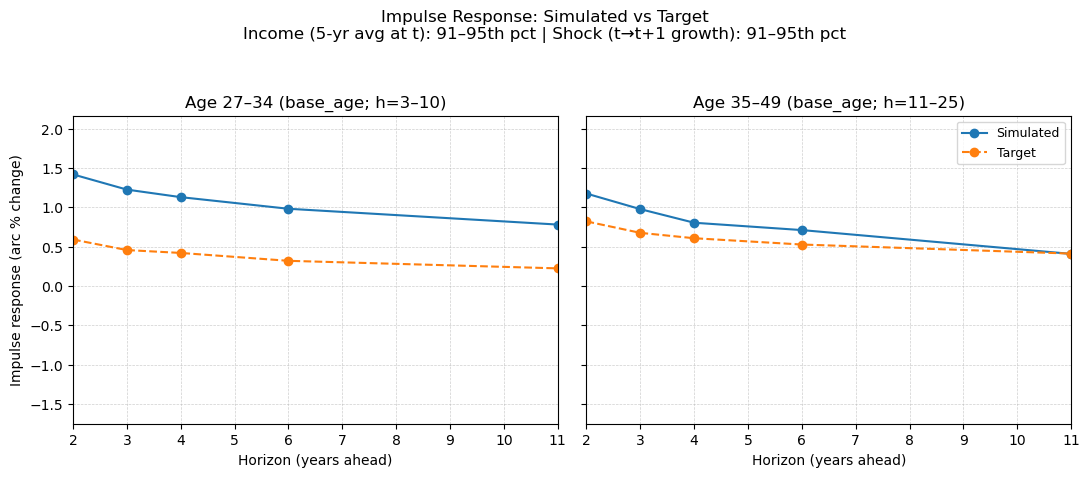

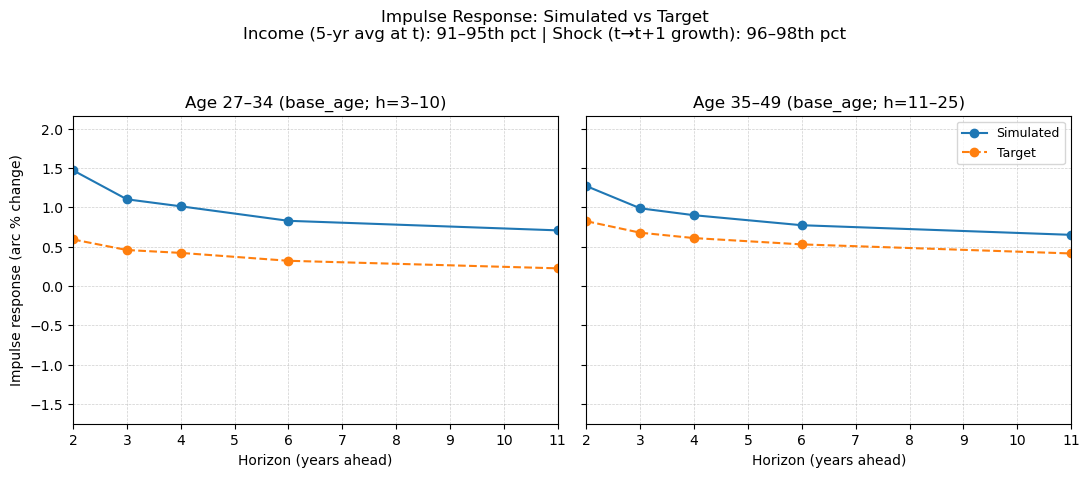

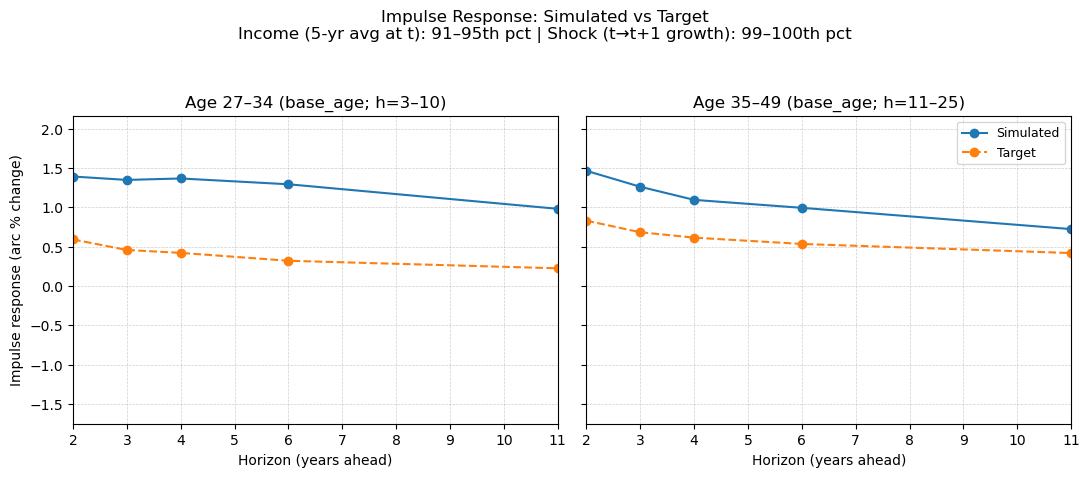

###########################################################################################
###########################################################################################
96–100th pct
###########################################################################################
###########################################################################################


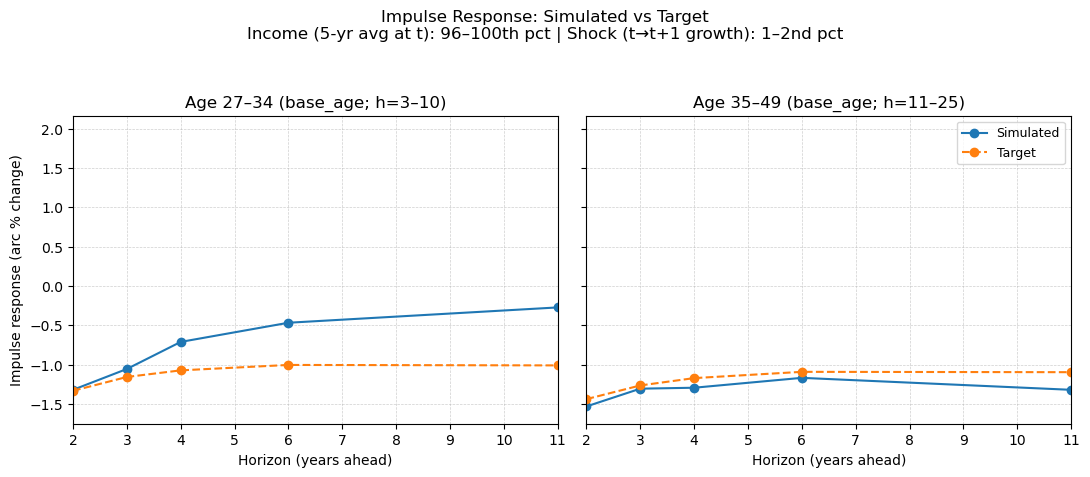

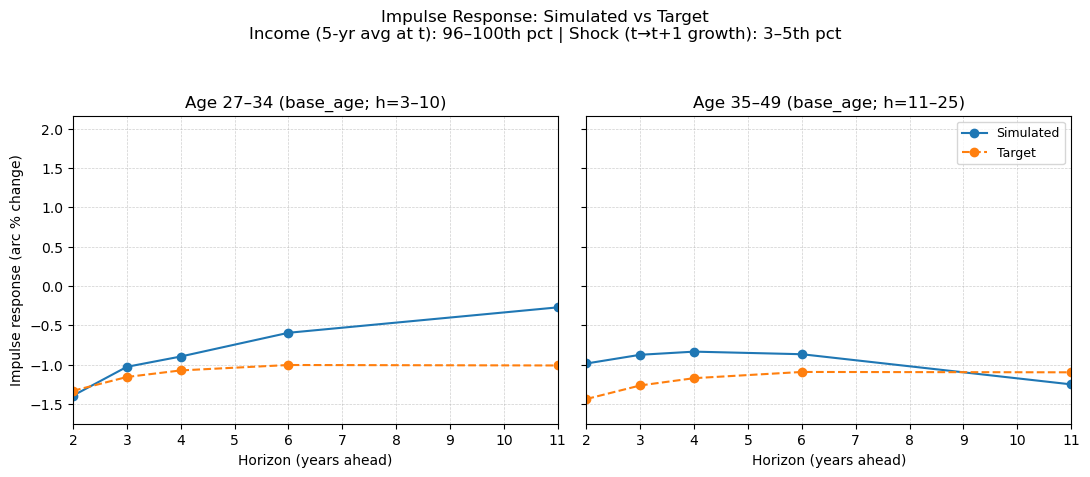

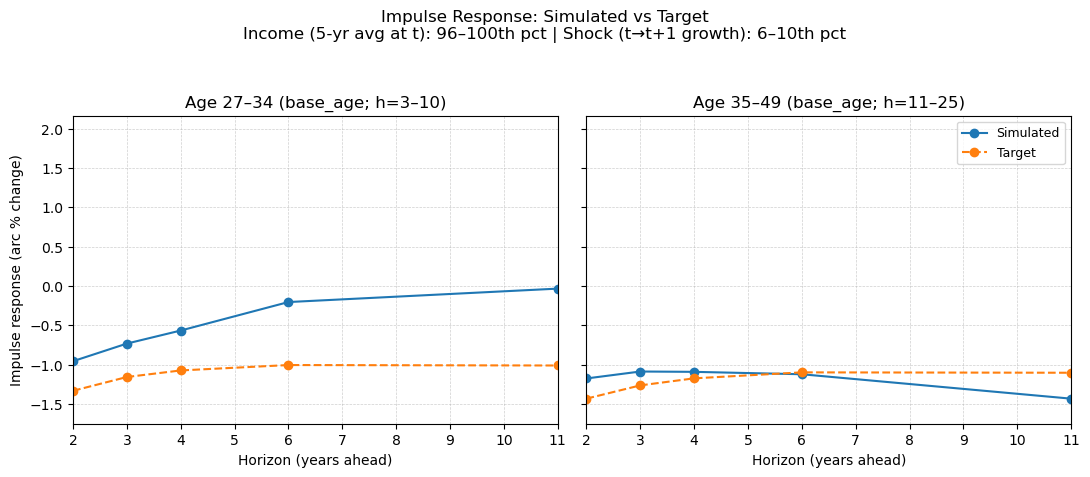

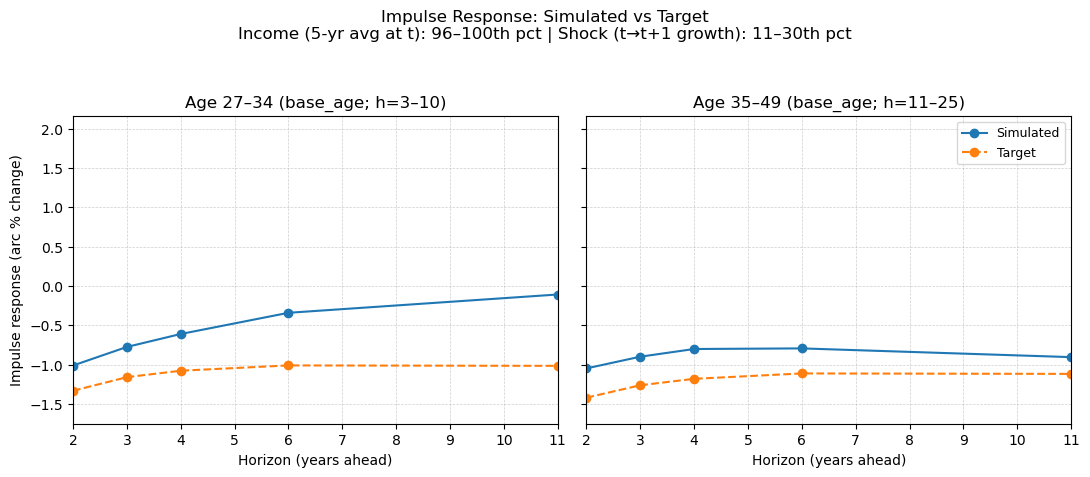

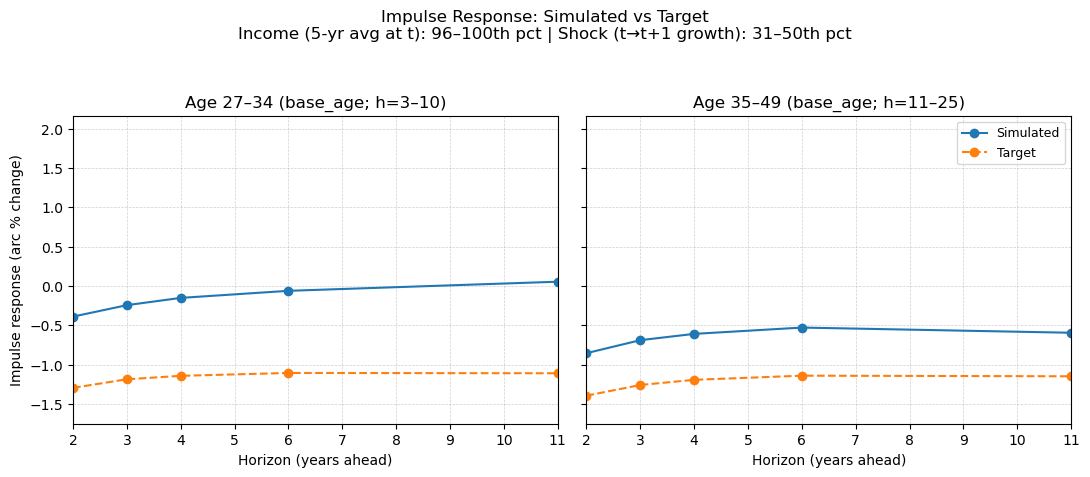

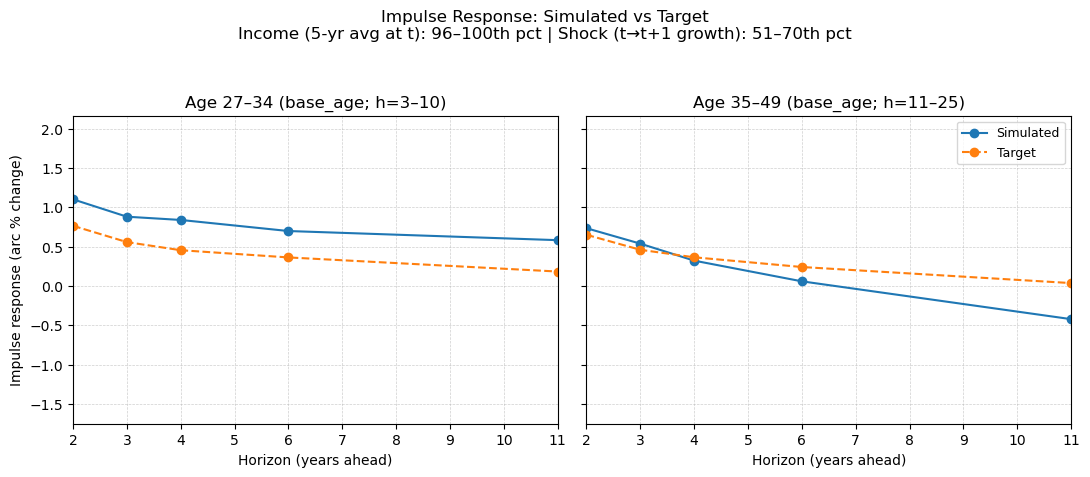

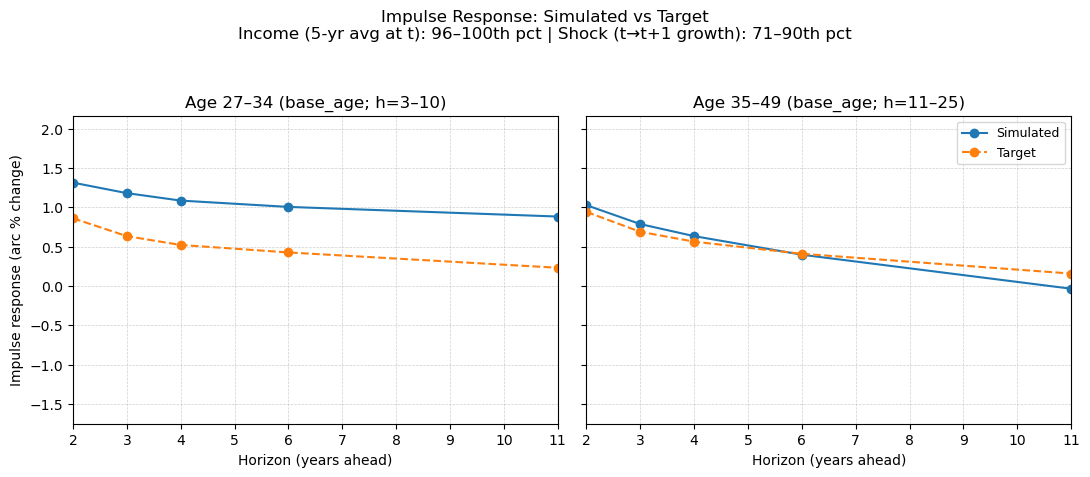

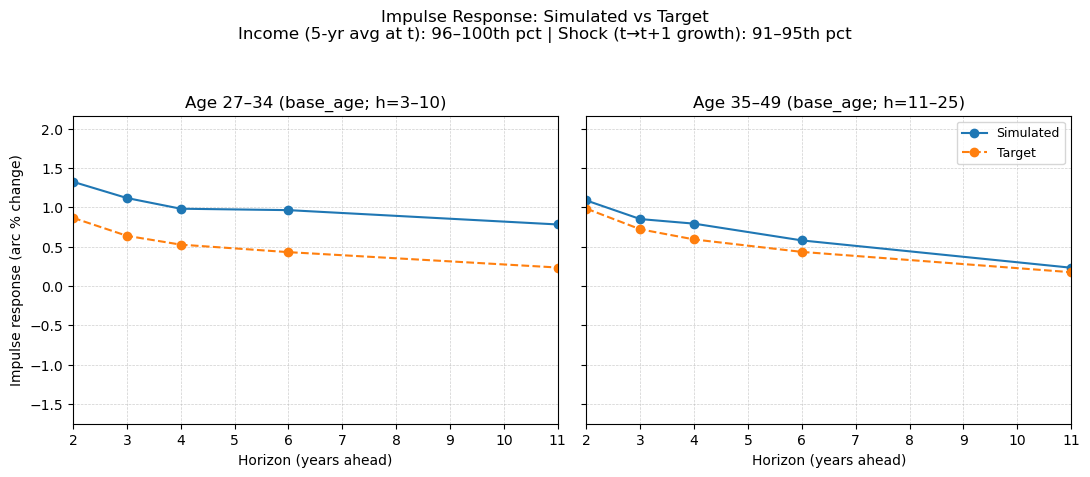

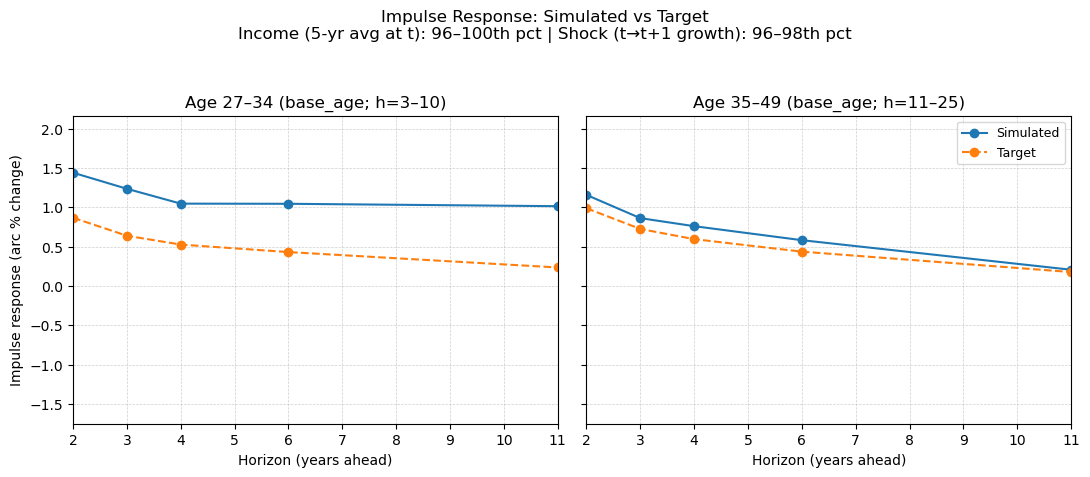

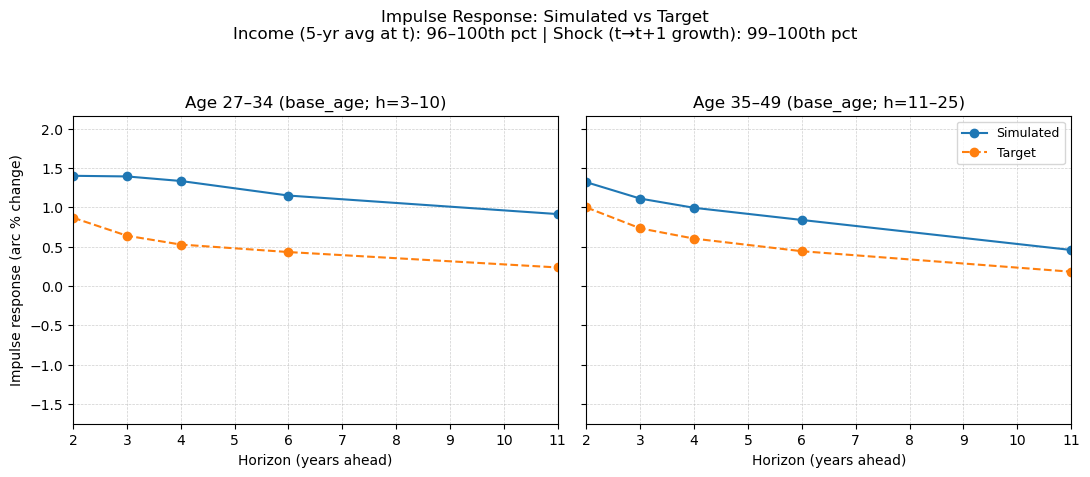

Would save 80 figures to: C:\Users\adv23\Dropbox\John-Jackson-Steve 2023\guvenen_2021_replication\targeted_moments_stata\out (save is currently commented out)


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ----------------------------
# INPUT
# ----------------------------
path = Path(r"C:\Users\adv23\Dropbox\John-Jackson-Steve 2023\guvenen_2021_replication\targeted_moments_stata\out\sim_impulse_vs_target.csv")
df = pd.read_csv(path)
df.columns = [c.strip() for c in df.columns]

# Ensure numeric types
for c in ["agegrp", "incbin", "shockbin"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Horizons you want
H = [2, 3, 4, 6, 11]
S_cols = [f"S{h}" for h in H]
D_cols = [f"Dhat_y{h}" for h in H]

missing_cols = [c for c in (S_cols + D_cols) if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# ----------------------------
# SETTINGS
# ----------------------------
age_panels = [
    (1, "Age 27–34 (base_age; h=3–10)"),
    (2, "Age 35–49 (base_age; h=11–25)"),
]

outdir = path.parent

income_bin_labels = {
    1: "1–5th pct",
    2: "6–10th pct",
    3: "11–30th pct",
    4: "31–50th pct",
    5: "51–70th pct",
    6: "71–90th pct",
    7: "91–95th pct",
    8: "96–100th pct",
}

shock_bin_labels = {
    1: "1–2nd pct",
    2: "3–5th pct",
    3: "6–10th pct",
    4: "11–30th pct",
    5: "31–50th pct",
    6: "51–70th pct",
    7: "71–90th pct",
    8: "91–95th pct",
    9: "96–98th pct",
    10: "99–100th pct",
}

# ----------------------------
# PRECOMPUTE y-axis limits across ALL cells so panels comparable
# ----------------------------
vals = []
for col in S_cols + D_cols:
    vals.append(pd.to_numeric(df[col], errors="coerce"))
all_vals = pd.concat(vals, axis=0).dropna()

ymin, ymax = all_vals.min(), all_vals.max()
pad = 0.05 * (ymax - ymin) if ymax > ymin else 1.0
ymin -= pad
ymax += pad

# ----------------------------
# LOOP OVER INCBINS (outer) and SHOCKBINS (inner)
# ----------------------------
incbins = sorted(df["incbin"].dropna().unique())
shockbins = sorted(df["shockbin"].dropna().unique())

for ib in incbins:
    inc_label = income_bin_labels.get(int(ib), f"Bin {int(ib)}")
    
    print("###########################################################################################")
    print("###########################################################################################")
    print(inc_label)
    print("###########################################################################################")
    print("###########################################################################################")

    for sb in shockbins:
        shock_label = shock_bin_labels.get(int(sb), f"Bin {int(sb)}")

        fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

        fig.suptitle(
            f"Impulse Response: Simulated vs Target\n"
            f"Income (5-yr avg at t): {inc_label} | "
            f"Shock (t→t+1 growth): {shock_label}",
            y=1.05
        )


        for ax, (ag, ag_label) in zip(axes, age_panels):
            sub = df[(df["incbin"] == ib) & (df["shockbin"] == sb) & (df["agegrp"] == ag)].copy()

            if sub.empty:
                ax.set_title(ag_label)
                ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
                ax.set_xlim(min(H), max(H))
                ax.set_ylim(ymin, ymax)
                ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
                continue

            # If multiple rows exist (shouldn't), average them
            S = sub[S_cols].mean().values
            D = sub[D_cols].mean().values

            ax.plot(H, S, marker="o", linewidth=1.5, label="Simulated")
            ax.plot(H, D, marker="o", linewidth=1.5, linestyle="--", label="Target")

            ax.set_title(ag_label)
            ax.set_xlabel("Horizon (years ahead)")
            ax.set_xlim(min(H), max(H))
            ax.set_ylim(ymin, ymax)
            ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

        axes[0].set_ylabel("Impulse response (arc % change)")
        axes[-1].legend(loc="best", fontsize=9)
        fig.tight_layout()

        outfile = outdir / f"irf_sim_vs_target_incbin_{int(ib)}_shockbin_{int(sb)}.png"
        # fig.savefig(outfile, dpi=200, bbox_inches="tight")  # keep commented for now
        plt.show()

print(f"Would save {len(incbins)*len(shockbins)} figures to: {outdir} (save is currently commented out)")
